# RQ3 results figures -- plan

Builds the figures backing RQ3's plot-specific curve-deviation claims in
`documentation/august_draft/5_Chapter_results_evaluation/f_written_draft_v1_18thaug.tex`.

**Figures in this notebook**

| Figure | Status | Question it answers |
|---|---|---|
| R3-1 | **Must-have** | Does GNNWR's accuracy edge over EN/XGBoost correspond to it actually reducing leftover spatial structure, and does that hold on both cohorts? |
| R3-2 | **Must-have** | Where do growth-curve deviations occur, and does the spatial pattern line up with the proposed reasons (boundary proximity, compartment archetype)? |
| R3-3 | Optional (build if time allows) | Do EN, XGBoost, and GNNWR agree on which variable matters most, on both cohorts? |

**Not built here (cut for time)**: R3-4 (compartment-archetype representative trajectories, small
multiples) was considered and dropped -- illustrative only, and R3-2's Panel B already shows
archetypes spatially; its own plotting code did not exist yet in this project either.

**Data-source honesty note**: R3-1 Panel A (EN/XGBoost/GNNWR R2 by set) and R3-3 (rank agreement)
are transcribed from `TEMP_results/TEMP_rq3_en_xgb_results_2026-08-11.tex` and
`TEMP_results/TEMP_rq3_gnnwr_results_2026-08-11.tex` with citation, since this session did not
independently verify every underlying per-set predictions.csv path for RQ3's EN/XGBoost fits.
**Panel B is now FINAL, not placeholder** -- transcribed exactly from the published
`tab:results-rq3-morans` table in the results draft (2026-08-19), itself the corrected
semivariogram-informed Moran's I re-run. R3-1 Panel C, R3-2 (all panels), and the GNNWR pooling
all use live, verified file reads.

**Style / uncertainty convention**: see `notebooks/results_figures_style.py`. R3-1 Panel A uses
the same **1,000-resample** bootstrap CI convention as everywhere else in this project. Panel B
(Moran's I) has no CI. R3-2 has no uncertainty anywhere -- deterministic target values and raw
observations.

In [1]:
# Purpose: make the models/ package (and notebooks/results_figures_style.py) importable from
# this notebook. Same convention already used across this project's other notebooks (e.g.
# notebooks/model_results/baseline_results.ipynb): walk upward until a folder containing both
# README.md and data/ is found -- that is the project root.

import sys
from pathlib import Path

notebook_directory = Path.cwd().resolve()
project_root = next(
    folder for folder in [notebook_directory, *notebook_directory.parents]
    if (folder / "README.md").exists() and (folder / "data").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("project_root:", project_root)

project_root: /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from models.common.geo import load_compartment_boundaries, load_plot_coordinates
from notebooks.results_figures_style import (
    COLOR_EN, COLOR_XGBOOST, COLOR_GNNWR, COLOR_NEUTRAL_EDGE, DIVERGING_CMAP, apply_rcparams,
)

apply_rcparams()

FIGURES_DIR = project_root / "figures" / "fig_results"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

GNNWR_DIR = project_root / "outputs" / "growth_curve_attribution" / "gnnwr"
N_FOLDS = 5
SETS = ["Set2", "Set3", "Set4"]

## Figure R3-1 -- GNNWR's accuracy edge and its spatial-structure meaning

**Research question**: RQ3 items 2-3 -- does GNNWR's R2 edge over EN/XGBoost on 4survey
correspond to an independent reduction in residual Moran's I, and does that correspondence hold
or break down on 6survey?

**Data**: Panels A/B transcribed (with citation) from `TEMP_rq3_en_xgb_results_2026-08-11.tex` /
`TEMP_rq3_gnnwr_results_2026-08-11.tex`. Panel C -- pools the 5 fold
`gnnwr_nested_set4_gated_all_vif_4survey_reffull_fold{0-4}of5_test_predictions.csv` files' own
`coef_CanopyCover`, `coef_topex`, `x`, `y`, `cpmt` columns into one per-plot value -- live read, no
new fitting.

**Encoding**: Panel A -- 4survey only (R2, one point+CI per model per set); Panel B -- both
cohorts (Moran's I by set, one line per model); Panel C -- **two** diverging maps side by side:
GNNWR's own local `CanopyCover` coefficient (stable across EN/LMM/GNNWR everywhere) next to its
local `topex` coefficient (the variable EN and LMM disagree on) -- the direct visual for the
cross-cutting "model families disagree informatively" thread this project wants kept visible
across Q1/Q2, not two unrelated maps.

In [3]:
# Transcribed from TEMP_rq3_en_xgb_results_2026-08-11.tex and TEMP_rq3_gnnwr_results_2026-08-11.tex
# -- see the markdown cell above for why these are hardcoded rather than re-read live.
PANEL_A_4SURVEY = {  # {set: {model: (r2, ci_low, ci_high)}}
    "Set2": {"Elastic Net": (0.286, 0.241, 0.325), "XGBoost": (0.266, 0.214, 0.308), "GNNWR": (0.320, 0.270, 0.369)},
    "Set3": {"Elastic Net": (0.274, 0.223, 0.316), "XGBoost": (0.281, 0.235, 0.320), "GNNWR": (0.319, 0.263, 0.365)},
    "Set4": {"Elastic Net": (0.240, 0.192, 0.286), "XGBoost": (0.250, 0.201, 0.295), "GNNWR": (0.294, 0.236, 0.347)},
}

# FINAL 2026-08-19 -- exact values, transcribed directly from the published
# tab:results-rq3-morans table in f_written_draft_v1_18thaug.tex (lines 217-222), not an estimate
# or a scaled placeholder. "no structure" (semivariogram flat even at the 5,000m search window,
# genuine null) is represented as None -- plotted as explicitly missing, never interpolated. The
# 6survey values that DID resolve only did so after widening the search window to 10,000m
# (exceeds_window status, not resolved) and are not significant (p=0.05-0.31) -- real numbers,
# but provisional, not equivalent evidence to the resolved 4survey column (see the table's own
# caption). Every 4survey cell is resolved and significant (p=0.001).
PANEL_B_MORANS_I = {  # {cohort: {set: {model: morans_i}}}
    "4survey": {
        "Set2": {"Elastic Net": 0.147, "XGBoost": 0.148, "GNNWR": 0.100},
        "Set3": {"Elastic Net": 0.167, "XGBoost": 0.144, "GNNWR": 0.109},
        "Set4": {"Elastic Net": 0.145, "XGBoost": 0.107, "GNNWR": 0.082},
    },
    "6survey": {  # None = no structure (unresolved even at 10,000m) -- plotted as explicitly missing
        "Set2": {"Elastic Net": None, "XGBoost": -0.0002, "GNNWR": -0.0002},  # XGB/GNNWR: exceeds_window, ns
        "Set3": {"Elastic Net": None, "XGBoost": None, "GNNWR": None},
        "Set4": {"Elastic Net": None, "XGBoost": -0.0002, "GNNWR": -0.0002},  # XGB/GNNWR: exceeds_window, ns
    },
}

## Q2 Figure 1 -- GNNWR's accuracy edge + Moran's I corroboration

**Pairs with**: the "GNNWR beats both global models on point estimates... corroborated by an
independent reduction in residual Moran's I" paragraph -- these are one claim (edge exists, AND
is corroborated), so they stay one figure, not split further.

**Redesign from the old R3-1**: Panel A was 9 separate point+CI markers (3 models x 3 sets),
making the pairwise "does GNNWR sit ahead" comparison harder to read than necessary. Now a
dumbbell: GNNWR's point connected by a line to the BEST of {EN, XGBoost} for that set, one line
per set, coloured by whether GNNWR wins.

**2026-08-20 revision**: both dumbbell points now carry their own 95% cluster-bootstrap CI as
whiskers (this data already existed in `PANEL_A_4SURVEY`, just wasn't plotted before), so the
figure states whether GNNWR's edge survives its own uncertainty, not just where the point
estimates sit. The R^2 gap is also printed directly above each line -- the headline number, not
left for the reader to eyeball from two dots.

**2026-08-21 revision -- Panel B**: was a 6-line plot (3 models x 2 cohorts), and every 6survey
value is unresolved or ~0 (no detectable spatial structure at any set), so those 3 lines collapsed
on top of each other with overlapping "x" markers and added nothing to the corroboration claim.
Redesigned as a dumbbell for 4survey only, mirroring Panel A exactly -- GNNWR vs. the best of
{EN, XGBoost}, gap labelled (lower Moran's I wins here, the opposite direction from Panel A's R^2).
6survey is now stated as omitted, with why, in a caption -- not plotted as if it were a meaningful
comparison.

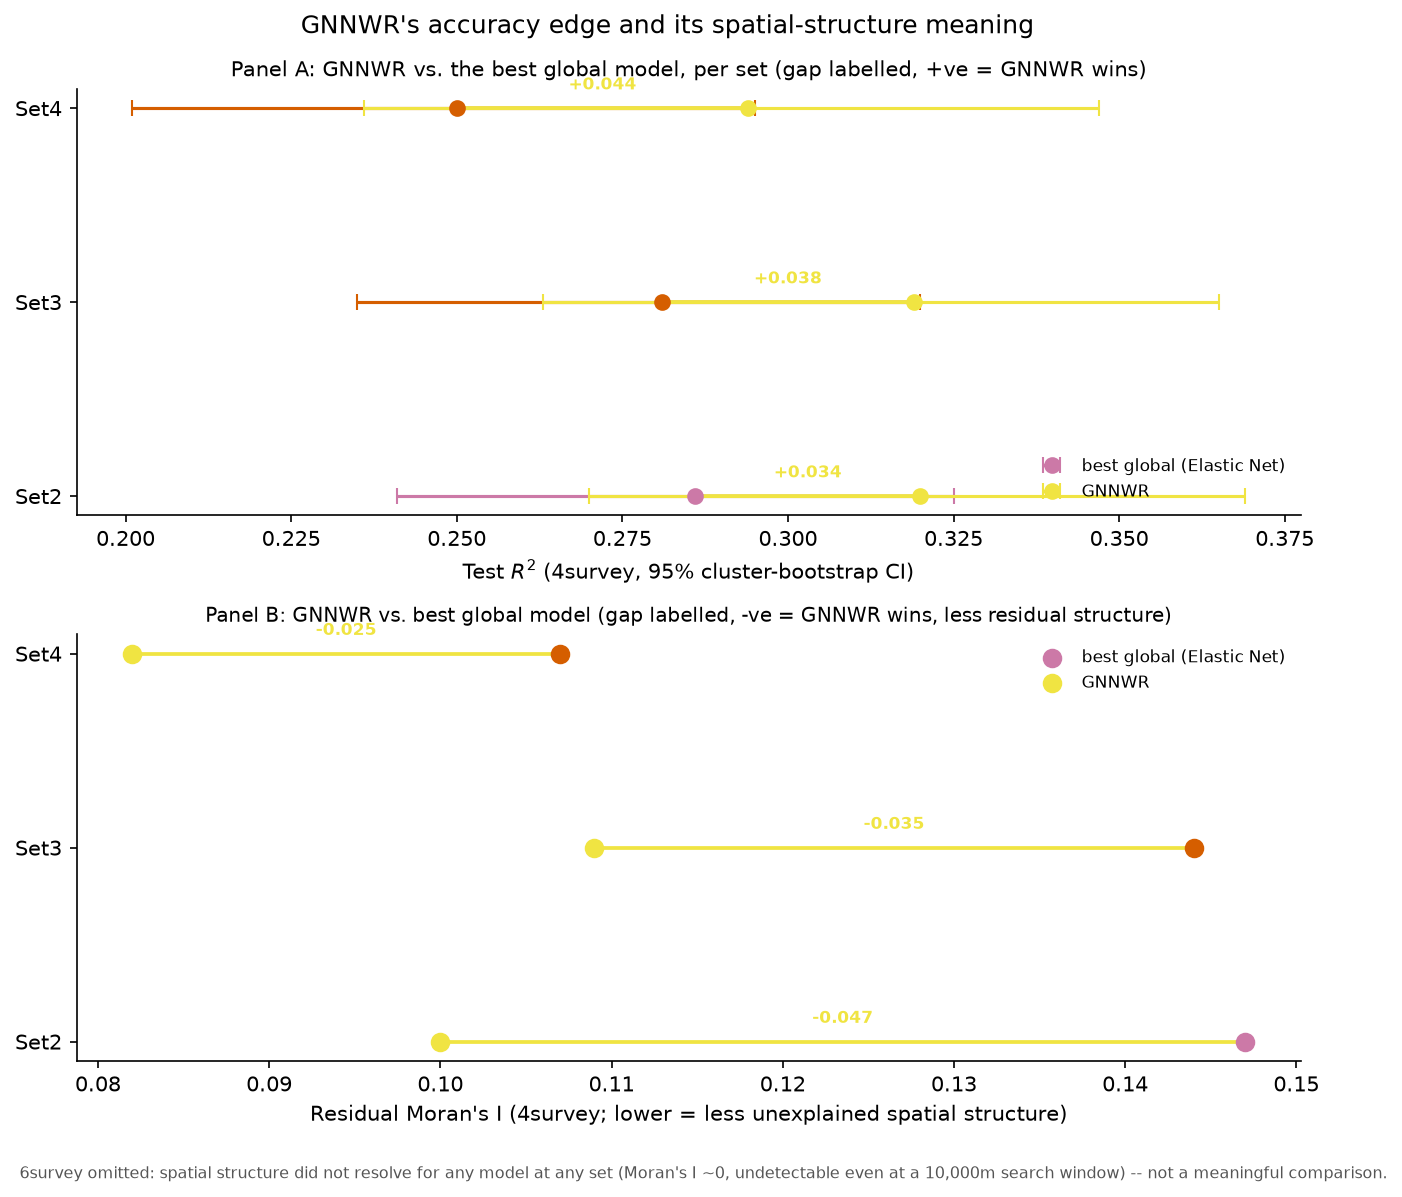

In [4]:
fig, (ax_a, ax_b) = plt.subplots(2, 1, figsize=(9, 8))
model_colors_r3 = {"Elastic Net": COLOR_EN, "XGBoost": COLOR_XGBOOST, "GNNWR": COLOR_GNNWR}

# --- Panel A: dumbbell, GNNWR vs. the BEST global model, per set -- the actual pairwise claim.
# Both points now carry their own cluster-bootstrap 95% CI (whiskers), and the R^2 gap is stated
# as a number next to each line -- the CI values were already sitting in PANEL_A_4SURVEY unused
# (only [0], the point estimate, was read before), so this is real data, not a new estimate. ---
for i, set_name in enumerate(SETS):
    global_candidates = {m: PANEL_A_4SURVEY[set_name][m][0] for m in ("Elastic Net", "XGBoost")}
    best_global_model = max(global_candidates, key=global_candidates.get)
    best_global_r2, best_global_lo, best_global_hi = PANEL_A_4SURVEY[set_name][best_global_model]
    gnnwr_r2, gnnwr_lo, gnnwr_hi = PANEL_A_4SURVEY[set_name]["GNNWR"]
    winner_color = COLOR_GNNWR if gnnwr_r2 > best_global_r2 else model_colors_r3[best_global_model]
    ax_a.plot([best_global_r2, gnnwr_r2], [i, i], color=winner_color, linewidth=1.8, zorder=1)
    ax_a.errorbar([best_global_r2], [i], xerr=[[best_global_r2 - best_global_lo], [best_global_hi - best_global_r2]],
                  fmt="o", color=model_colors_r3[best_global_model], markersize=7, capsize=4, zorder=2,
                  label=f"best global ({best_global_model})" if i == 0 else None)
    ax_a.errorbar([gnnwr_r2], [i], xerr=[[gnnwr_r2 - gnnwr_lo], [gnnwr_hi - gnnwr_r2]],
                  fmt="o", color=COLOR_GNNWR, markersize=7, capsize=4, zorder=2,
                  label="GNNWR" if i == 0 else None)
    gap = gnnwr_r2 - best_global_r2
    ax_a.annotate(f"{gap:+.3f}", xy=((best_global_r2 + gnnwr_r2) / 2, i), xytext=(0, 9),
                  textcoords="offset points", ha="center", fontsize=8, fontweight="bold", color=winner_color)
ax_a.set_yticks(range(len(SETS)))
ax_a.set_yticklabels(SETS)
ax_a.set_xlabel("Test $R^2$ (4survey, 95% cluster-bootstrap CI)")
ax_a.legend(fontsize=8, frameon=False, loc="lower right")
ax_a.set_title("Panel A: GNNWR vs. the best global model, per set (gap labelled, +ve = GNNWR wins)", fontsize=10)

# --- Panel B, redesigned 2026-08-21: was a 6-line plot (3 models x 2 cohorts) -- for 6survey
# EVERY value is unresolved or ~0 (no detectable spatial structure at any set), so those 3 lines
# collapsed on top of each other right at y=0 with overlapping "x" markers, and did nothing to
# support the corroboration claim. Now a dumbbell for 4survey only (the only cohort where every
# value actually resolved), mirroring Panel A's design exactly -- GNNWR vs. the BEST of
# {EN, XGBoost}, one row per set, gap labelled. For Moran's I, "best" = LOWER (less residual
# spatial structure), the opposite direction from Panel A's R^2. 6survey is stated as omitted,
# with why, rather than plotted as if it were a meaningful comparison. ---
for i, set_name in enumerate(SETS):
    global_candidates = {m: PANEL_B_MORANS_I["4survey"][set_name][m] for m in ("Elastic Net", "XGBoost")}
    best_global_model = min(global_candidates, key=global_candidates.get)  # lower Moran's I wins here
    best_global_morans = global_candidates[best_global_model]
    gnnwr_morans = PANEL_B_MORANS_I["4survey"][set_name]["GNNWR"]
    winner_color = COLOR_GNNWR if gnnwr_morans < best_global_morans else model_colors_r3[best_global_model]
    ax_b.plot([best_global_morans, gnnwr_morans], [i, i], color=winner_color, linewidth=1.8, zorder=1)
    ax_b.scatter([best_global_morans], [i], color=model_colors_r3[best_global_model], s=70, zorder=2,
                 label=f"best global ({best_global_model})" if i == 0 else None)
    ax_b.scatter([gnnwr_morans], [i], color=COLOR_GNNWR, s=70, zorder=2,
                 label="GNNWR" if i == 0 else None)
    gap = gnnwr_morans - best_global_morans
    ax_b.annotate(f"{gap:+.3f}", xy=((best_global_morans + gnnwr_morans) / 2, i), xytext=(0, 9),
                  textcoords="offset points", ha="center", fontsize=8, fontweight="bold", color=winner_color)
ax_b.set_yticks(range(len(SETS)))
ax_b.set_yticklabels(SETS)
ax_b.set_xlabel("Residual Moran's I (4survey; lower = less unexplained spatial structure)")
ax_b.legend(fontsize=8, frameon=False, loc="upper right")
ax_b.set_title("Panel B: GNNWR vs. best global model (gap labelled, -ve = GNNWR wins, less residual structure)",
               fontsize=9.5)
fig.text(0.02, 0.01, "6survey omitted: spatial structure did not resolve for any model at any set "
         "(Moran's I ~0, undetectable even at a 10,000m search window) -- not a meaningful comparison.",
         fontsize=7.5, color="#555555")

fig.suptitle("GNNWR's accuracy edge and its spatial-structure meaning", fontsize=12)
plt.tight_layout(rect=[0, 0.035, 1, 1])  # leaves room at the bottom for the 6survey caption
plt.show()

## Q2 Figure 2 -- GNNWR's local coefficients (with the limitation stated on the figure)

**Pairs with**: the local-coefficient / cross-model-agreement paragraph (CanopyCover ranks first
everywhere, topex disagrees between EN and LMM -- the same cross-cutting thread Q1's own maps
show).

**Redesign from the old Panel C**: same two maps (CanopyCover, topex), but (1) a robust colour
range (98th percentile, not raw max -- same fix already applied to Q1's residual map) so one or
two outlier compartments don't wash out contrast for the typical range, and (2) the linear-model
limitation is now printed directly on the figure, not left to prose alone -- a viewer looking at
just this image should not conclude it proves genuine spatial non-stationarity.

**2026-08-20 revision**: the "stable vs unstable" claim is now stated as a number in each panel's
own title (% of compartments where the local coefficient is positive/negative), computed live
from the same compartment-mean values the map itself colours -- not left for the reader to infer
from how much a colour pattern "wobbles".

56,114 plots with pooled local coefficients
       coef_CanopyCover    coef_topex
count      56114.000000  56114.000000
mean          23.573002      3.423900
std            5.663675      7.756267
min            3.814763    -16.430653
25%           20.350253     -0.363517
50%           23.667198      2.559359
75%           26.471139      5.792060
max           40.144080     39.785873


CanopyCover positive in 100% of compartments
topex positive in 72%, negative in 28% of compartments


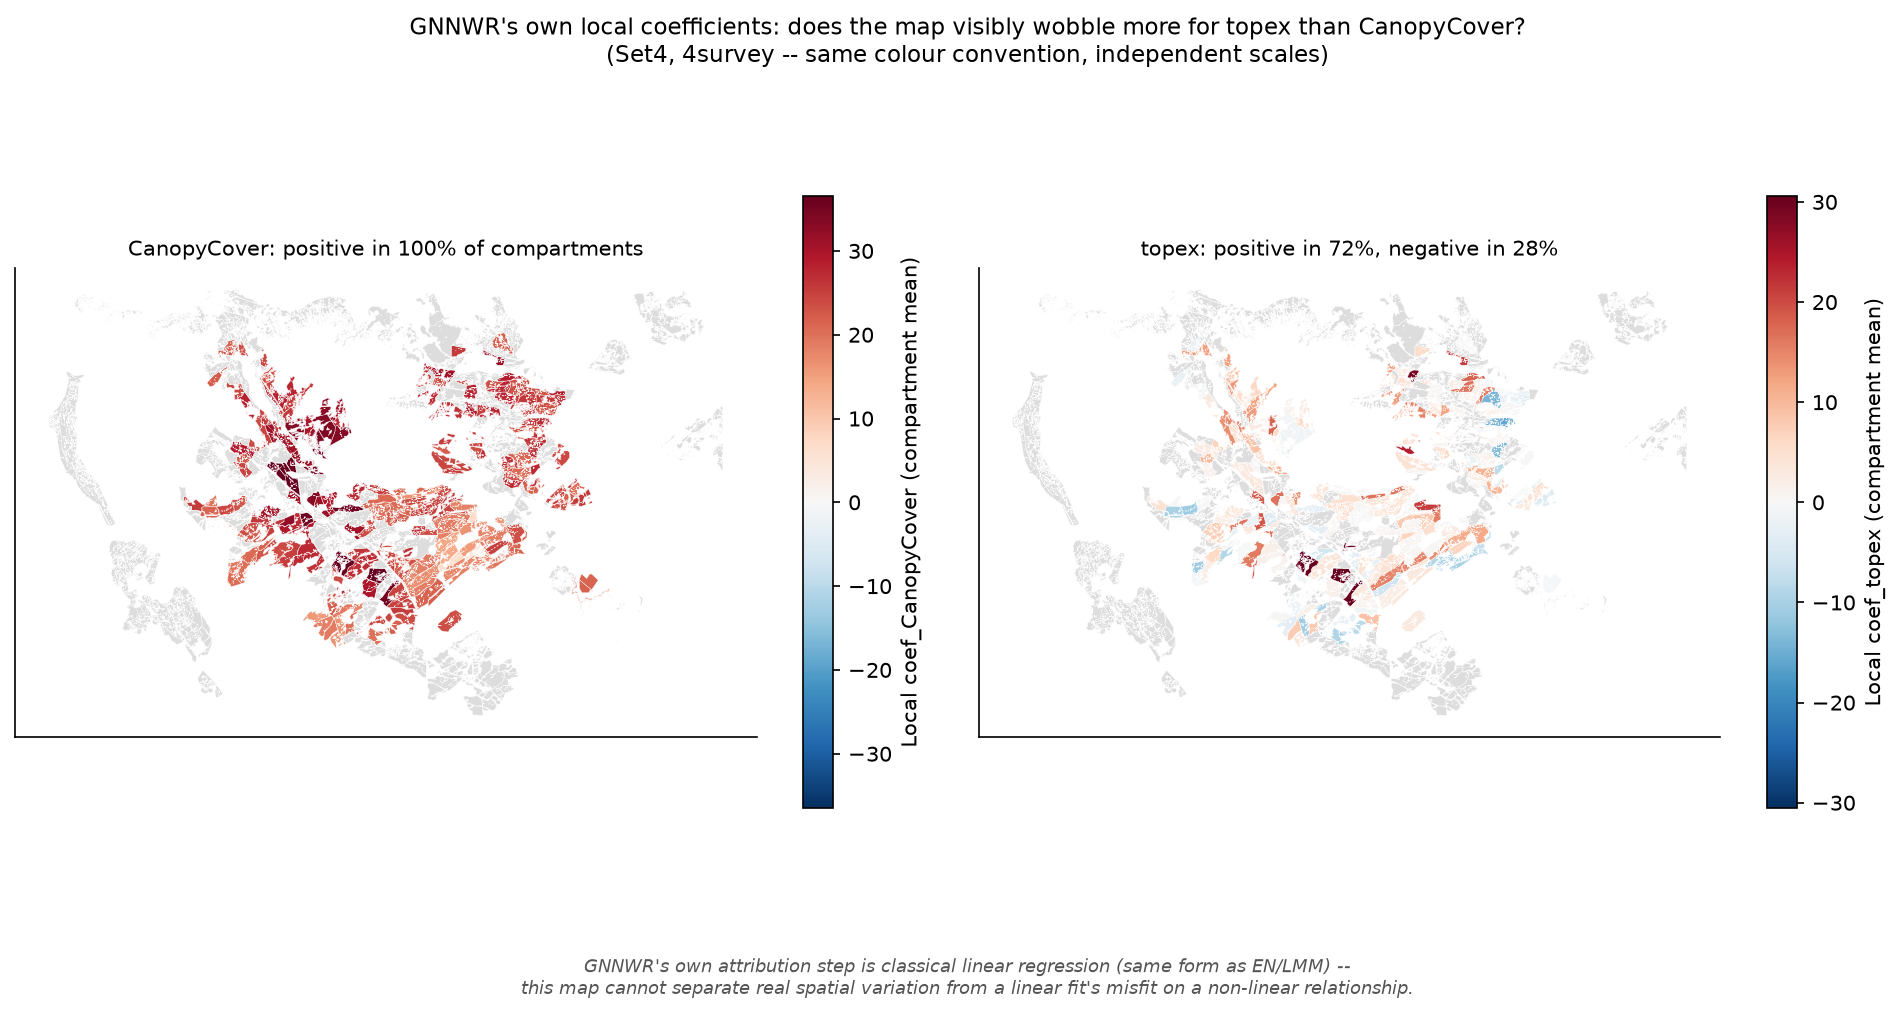

In [5]:
# --- Panel C: pool GNNWR's own local CanopyCover AND topex coefficients across the 5 folds, one
# value per plot -- CanopyCover is the STABLE variable (agrees across EN/LMM/GNNWR everywhere),
# topex is the UNSTABLE one (EN vs LMM sign-flip, per Q1) -- mapping them side by side is the
# direct visual for that cross-cutting "model families disagree informatively" thread, not two
# unrelated maps. ---
gnnwr_frames = []
for fold in range(N_FOLDS):
    p = GNNWR_DIR / f"gnnwr_nested_set4_gated_all_vif_4survey_reffull_fold{fold}of5_test_predictions.csv"
    fold_df = pd.read_csv(p, usecols=["identification", "cpmt", "x", "y", "coef_CanopyCover", "coef_topex"])
    gnnwr_frames.append(fold_df)
gnnwr_pooled = pd.concat(gnnwr_frames, ignore_index=True).drop_duplicates(subset="identification")
print(f"{len(gnnwr_pooled):,} plots with pooled local coefficients")
print(gnnwr_pooled[["coef_CanopyCover", "coef_topex"]].describe())

compartment_mean_coefs = gnnwr_pooled.groupby("cpmt")[["coef_CanopyCover", "coef_topex"]].mean().reset_index()
boundaries = load_compartment_boundaries()
mapped = boundaries.merge(compartment_mean_coefs, on="cpmt", how="left")

# --- State the "stable vs unstable" claim as a number, not just a colour pattern -- this is what
# the figure is FOR: turning "eyeball whether the map wobbles" into a named statistic. ---
pct_canopy_positive = (compartment_mean_coefs["coef_CanopyCover"] > 0).mean() * 100
pct_topex_positive = (compartment_mean_coefs["coef_topex"] > 0).mean() * 100
pct_topex_negative = (compartment_mean_coefs["coef_topex"] < 0).mean() * 100
print(f"CanopyCover positive in {pct_canopy_positive:.0f}% of compartments")
print(f"topex positive in {pct_topex_positive:.0f}%, negative in {pct_topex_negative:.0f}% of compartments")

fig, (ax_c1, ax_c2) = plt.subplots(1, 2, figsize=(13, 6.8))
for ax, column, title in [
    (ax_c1, "coef_CanopyCover", f"CanopyCover: positive in {pct_canopy_positive:.0f}% of compartments"),
    (ax_c2, "coef_topex", f"topex: positive in {pct_topex_positive:.0f}%, negative in {pct_topex_negative:.0f}%"),
]:
    vmax = mapped[column].abs().quantile(0.98)  # robust range, not raw max -- same fix as R2b-1's Panel C
    norm = mpl.colors.TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)
    mapped.plot(column=column, cmap=DIVERGING_CMAP, norm=norm, ax=ax,
                edgecolor="white", linewidth=0.2, missing_kwds={"color": "#DDDDDD"})
    sm = plt.cm.ScalarMappable(cmap=DIVERGING_CMAP, norm=norm)
    fig.colorbar(sm, ax=ax, shrink=0.75, label=f"Local {column} (compartment mean)")
    ax.set_title(title, fontsize=10)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])

# The limitation stated ON the figure, not only in prose -- a viewer reading this map alone
# should not walk away thinking it proves genuine spatial non-stationarity.
fig.text(0.5, 0.02,
         "GNNWR's own attribution step is classical linear regression (same form as EN/LMM) --\n"
         "this map cannot separate real spatial variation from a linear fit's misfit on a non-linear relationship.",
         ha="center", fontsize=8.5, style="italic", color="#555555")

fig.suptitle("GNNWR's own local coefficients: does the map visibly wobble more for topex than CanopyCover?\n"
             "(Set4, 4survey -- same colour convention, independent scales)", fontsize=11)
plt.tight_layout(rect=[0, 0.08, 1, 1])  # leaves room at the bottom for the caveat text, not clipped
plt.show()

## Q2 Figure 3 -- where growth-curve deviations occur, and what explains them

**Pairs with**: the outlier-mechanism paragraph -- extreme deviations trace to the target's own
construction math (a forced yield-class growth rate `k`), not to biology or a spatially-varying
process. The map below shows WHERE deviations concentrate; the trajectory panel makes the
mechanism a stated number (each archetype's forced `k`), not just an inferred curve gap.

**Research question**: RQ3 items 4-6, 9 -- does the spatial pattern of `local_y_max_difference`
line up with boundary proximity and compartment archetype, and are the recurring worst-residual
plots visibly the same points the map and the trajectories are both talking about?

**Data**: Panel A -- `build_plot_level_table("4survey")` for the deviation map, plus the
**266-plot Tukey-fence population** (item 6, "the pattern scales to hundreds of plots"): standard
Tukey fence (`Q1-1.5*IQR`, `Q3+1.5*IQR`) on `y_max_fit`, reproduced live here -- confirmed to give
exactly 266 plots (0.47%) across 57 compartments, matching the published figure exactly (method
from `TEMP_rq3_method_broader_scan_sensitivity_2026-08-15.tex`). Shown as small black x
markers.

**2026-08-21**: the map used to also layer on the 8-plot cross-model recurring population (items
4-5, from `TEMP_results_attribution/rq3_outlier_disturbance_crossref.csv`), first as prominent
star/triangle markers, then as a mix of small x's plus 2 highlighted examples -- both versions
were flagged as too cluttered/confusing to read alongside the 266-plot population on the same
axes. That population is dropped from this map entirely; it's still real data, just no longer
shown here -- the SHAP grid figure below uses the full 8-plot `outliers_4survey` directly, so
items 4-5 are still answered, just by a different figure.

Panel B -- `rq3_compartment_archetype_check.py`'s `build_plot_table()` + `classify_compartments()`.

**Panel C -- redesigned, no longer outlier-tier examples.** One representative trajectory per
compartment archetype (up to 5 populated classes; "possible reset/measurement issue" is
empirically empty for 4survey, per this project's own earlier finding -- skipped, not
padded with a fake example). **Representative-selection rule (defined here since no existing
code in this project defines one -- `rq3_compartment_archetype_check.py`'s own script just prints
the first 5 compartments per pattern in whatever order they sort, not a deliberate "most
typical" choice):** for each archetype, pick the compartment whose `mean_target` and
`mean_residual_range` are jointly closest (smallest Euclidean distance after standardising both)
to that archetype's own group mean -- i.e. the most TYPICAL compartment of its class, not an
extreme one. Then take that compartment's own plot closest to the compartment's mean target,
by the same logic, one level down.

**2026-08-20**: this automatic rule doesn't guarantee the chosen PLOT's own trajectory visually
reads as its archetype's name (aggregate "closest to compartment mean" can still land on a plot
whose individual curve looks unremarkable). Two of the five are hand-overridden below with plots
that do visually match their label -- see the code cell's comment for the specific candidates
considered and why (including a rejected pick that was almost certainly a LiDAR artifact, not a
real trajectory). The benchmark line is also now extrapolated past the observed age range (a
model formula, not new data), and the deviation is shaded as an area rather than left as an
inferred gap between two lines.

In [6]:
from models.growth_curve_attribution.scale_comparison_check import build_plot_level_table
from models.growth_curve_attribution.rq3_compartment_archetype_check import build_plot_table, classify_compartments
from models.growth_curve_attribution.data import load_filtered_growth_curve_table

panel_a_table = build_plot_level_table("4survey")
print(f"Panel A: {len(panel_a_table):,} plots, local_y_max_difference range "
      f"[{panel_a_table['local_y_max_difference'].min():.1f}, {panel_a_table['local_y_max_difference'].max():.1f}] m")

panel_b_plot_table, _ = build_plot_table("4survey")
compartment_archetypes, _ = classify_compartments(panel_b_plot_table)
print(f"Panel B: {len(compartment_archetypes)} compartments classified")
print(compartment_archetypes["pattern"].value_counts())

# --- Real, cross-model-derived recurring outlier population (not a proxy threshold rule) ---
# Moved from TEMP_results/ to TEMP_results_attribution/ during the refocus reorganization
# (confirmed 2026-08-20 -- the old path no longer exists).
outlier_crossref = pd.read_csv(project_root / "TEMP_results_attribution" / "rq3_outlier_disturbance_crossref.csv")
outliers_4survey = outlier_crossref[outlier_crossref["cohort"] == "4survey"].copy()
outliers_4survey["sub_population"] = np.where(outliers_4survey["residual_range"] < 6, "smooth", "unstable")
# Join x/y from panel_a_table (already has one row per plot with coordinates) -- no new lookup needed.
outliers_4survey = outliers_4survey.merge(
    panel_a_table[["identification", "x", "y"]], on="identification", how="left",
)
flagged_compartments = sorted(outliers_4survey["cpmt"].unique().tolist())
print(f"Real recurring-outlier population (4survey): {len(outliers_4survey)} plots, "
      f"{outliers_4survey['sub_population'].value_counts().to_dict()}, "
      f"in {len(flagged_compartments)} compartments: {flagged_compartments}")

# NOTE: the 8-plot recurring-outlier population (outliers_4survey, computed above) is no longer
# drawn on the map -- 2026-08-21 feedback was that showing both it and the 266-plot Tukey
# population on the same axes was too confusing, even after shrinking/recolouring/dropping the
# highlighted-example markers. The map below now shows ONLY the Tukey population. outliers_4survey
# itself is kept (unchanged) because the SHAP grid figure further down still uses the full 8-plot
# population.

# --- 266-plot Tukey-fence population (item 6) -- standard fence on y_max_fit, live-computed. ---
y_max_fit_q1, y_max_fit_q3 = panel_a_table["y_max_fit"].quantile([0.25, 0.75])
y_max_fit_iqr = y_max_fit_q3 - y_max_fit_q1
tukey_low = y_max_fit_q1 - 1.5 * y_max_fit_iqr
tukey_high = y_max_fit_q3 + 1.5 * y_max_fit_iqr
tukey_flagged = panel_a_table[(panel_a_table["y_max_fit"] < tukey_low) | (panel_a_table["y_max_fit"] > tukey_high)]
print(f"Tukey-fence population: {len(tukey_flagged)} plots ({len(tukey_flagged) / len(panel_a_table) * 100:.2f}%), "
      f"{tukey_flagged['cpmt'].nunique()} compartments")

# --- Panel C archetype-representative selection (rule defined here, see markdown cell above for
# why: no existing code in this project picks a "most typical" compartment per archetype). ---
archetype_order = [
    "close to yldc / stable", "consistently above yldc", "consistently below yldc",
    "trajectory-break outlier", "moderate mismatch / mixed",
]
archetype_examples = {}
for pattern in archetype_order:
    pattern_compartments = compartment_archetypes[compartment_archetypes["pattern"] == pattern]
    if len(pattern_compartments) == 0:
        continue  # e.g. "possible reset / measurement issue" is empirically empty for 4survey
    # Standardise both columns before computing distance so neither dominates just from having a
    # larger raw scale -- "most typical" should weigh target-deviation and trajectory-instability
    # roughly equally, not whichever happens to have bigger numbers.
    group_mean_target = pattern_compartments["mean_target"].mean()
    group_mean_range = pattern_compartments["mean_residual_range"].mean()
    target_std = pattern_compartments["mean_target"].std() or 1.0
    range_std = pattern_compartments["mean_residual_range"].std() or 1.0
    distance = (
        ((pattern_compartments["mean_target"] - group_mean_target) / target_std) ** 2
        + ((pattern_compartments["mean_residual_range"] - group_mean_range) / range_std) ** 2
    ) ** 0.5
    representative_cpmt = pattern_compartments.loc[distance.idxmin(), "cpmt"]

    # One level down: the representative compartment's own most-typical plot, same logic.
    compartment_plots = panel_b_plot_table[panel_b_plot_table["cpmt"] == representative_cpmt]
    plot_distance = (compartment_plots["local_y_max_difference"] - compartment_plots["local_y_max_difference"].mean()).abs()
    representative_plot = compartment_plots.loc[plot_distance.idxmin(), "identification"]
    archetype_examples[pattern] = {"cpmt": representative_cpmt, "identification": representative_plot}

print("Archetype-representative plots:", archetype_examples)

  Rows before filtering: 287,064
  Removed by Age < 30 at the 2023 survey (whole plot dropped): 54,616 rows


  Removed by yield class between 2 and 50 (whole plot dropped): 0 rows
  Rows after filtering: 232,448


  Rows before filtering: 287,064
  Removed by Age < 30 at the 2023 survey (whole plot dropped): 54,616 rows


  Removed by yield class between 2 and 50 (whole plot dropped): 0 rows
  Rows after filtering: 232,448


  Disturbance cleaning: excluded 315 of 56,841 plots (clearfell-like or measurement-inconsistent) before fitting y_max


...

  Rows before filtering: 287,064
  Removed by Age < 30 at the 2023 survey (whole plot dropped): 54,616 rows


  Removed by yield class between 2 and 50 (whole plot dropped): 0 rows
  Rows after filtering: 232,448
  Rows before filtering: 287,064


  Removed by Age < 30 at the 2023 survey (whole plot dropped): 54,616 rows
  Removed by yield class between 2 and 50 (whole plot dropped): 0 rows
  Rows after filtering: 232,448


  Rows before filtering: 287,064
  Removed by Age < 30 at the 2023 survey (whole plot dropped): 54,616 rows
  Removed by yield class between 2 and 50 (whole plot dropped): 0 rows
  Rows after filtering: 232,448


Panel B: 231 compartments classified
pattern
moderate mismatch / mixed    159
trajectory-break outlier      26
close to yldc / stable        20
consistently above yldc       20
consistently below yldc        6
Name: count, dtype: int64
Real recurring-outlier population (4survey): 8 plots, {'smooth': 4, 'unstable': 4}, in 6 compartments: [1135.0, 2173.0, 2176.0, 2217.0, 2232.0, 2250.0]
Tukey-fence population: 266 plots (0.47%), 57 compartments
Archetype-representative plots: {'close to yldc / stable': {'cpmt': np.int32(2254), 'identification': np.int32(352047)}, 'consistently above yldc': {'cpmt': np.int32(1099), 'identification': np.int32(263295)}, 'consistently below yldc': {'cpmt': np.int32(2199), 'identification': np.int32(117292)}, 'trajectory-break outlier': {'cpmt': np.int32(1056), 'identification': np.int32(371789)}, 'moderate mismatch / mixed': {'cpmt': np.int32(2229), 'identification': np.int32(354657)}}


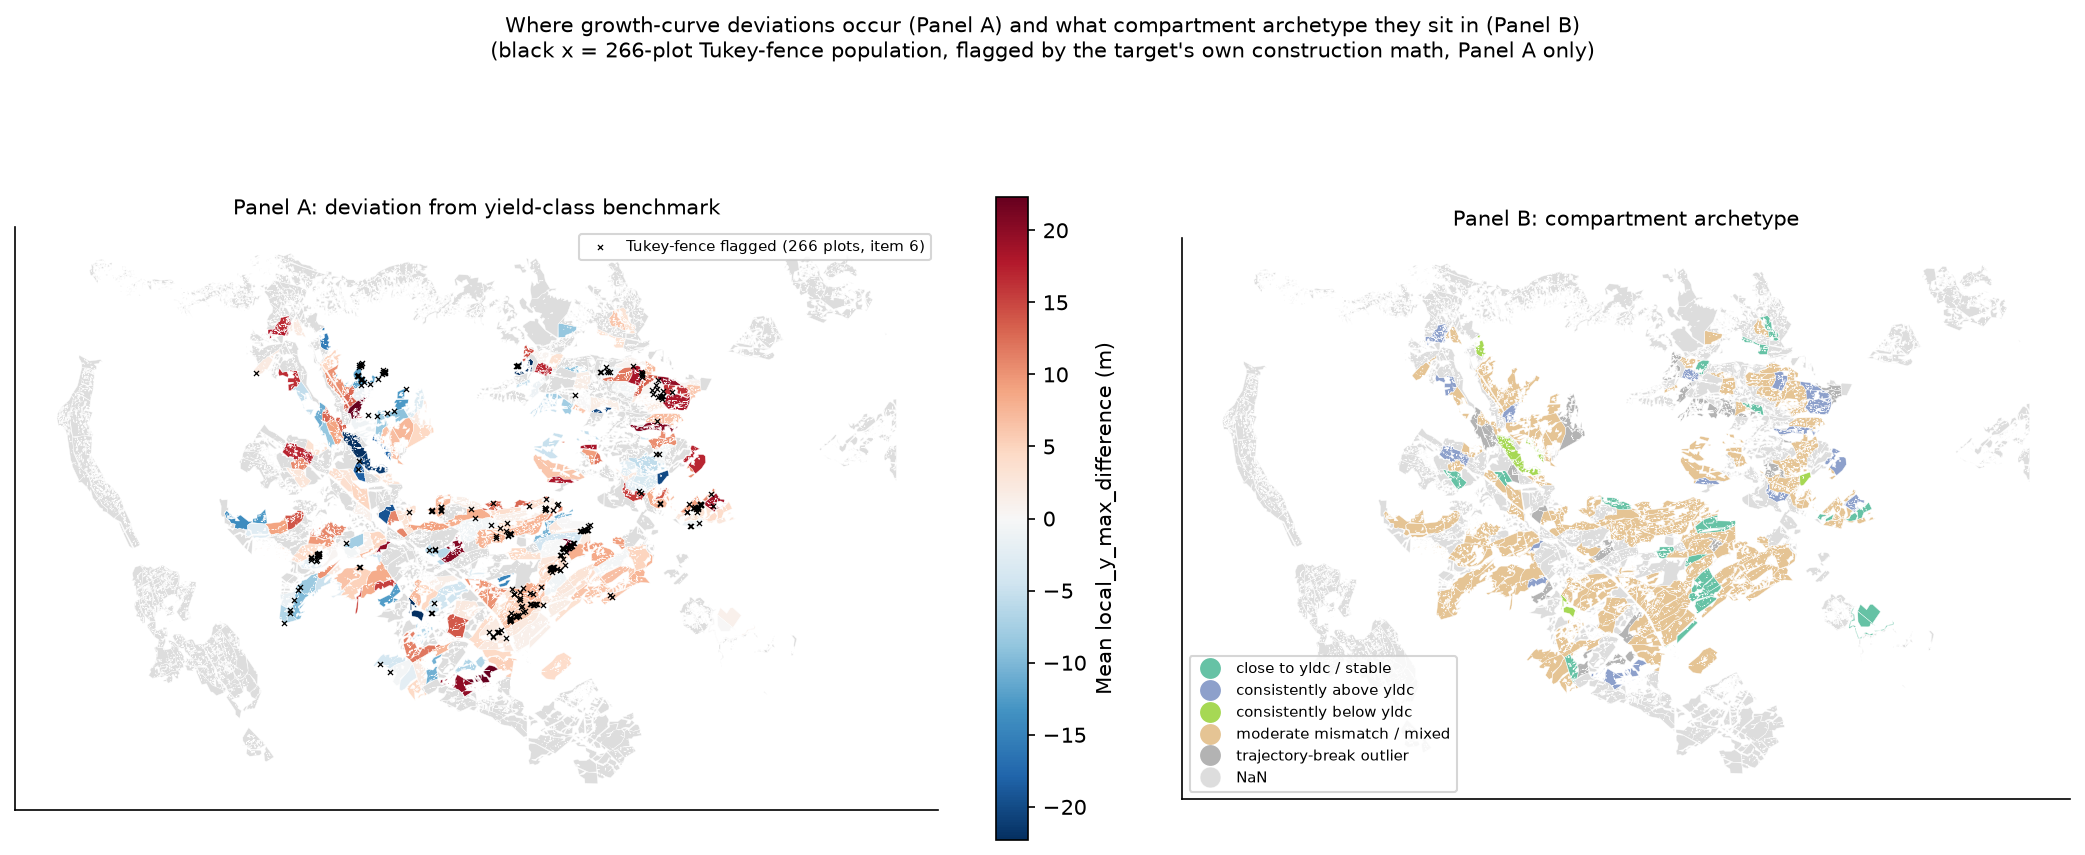

In [7]:
# width_ratios gives Panel A extra width -- its colorbar + legend box eat into its own map area,
# so at equal nominal widths its actual rendered map looked smaller than Panel B's (confirmed
# 2026-08-21 by inspecting the rendered PNG).
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(14, 6.5), sharex=False, sharey=False,
                                  gridspec_kw={"width_ratios": [1.3, 1]})

# --- Panel A: deviation map, compartment-mean local_y_max_difference ---
compartment_mean_deviation = panel_a_table.groupby("cpmt")["local_y_max_difference"].mean().reset_index()
boundaries = load_compartment_boundaries()
mapped_a = boundaries.merge(compartment_mean_deviation, on="cpmt", how="left")
vmax = mapped_a["local_y_max_difference"].abs().quantile(0.98)  # robust to a handful of extreme outlier compartments
norm = mpl.colors.TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)
mapped_a.plot(column="local_y_max_difference", cmap=DIVERGING_CMAP, norm=norm, ax=ax_a,
              edgecolor="white", linewidth=0.2, missing_kwds={"color": "#DDDDDD"})
sm = plt.cm.ScalarMappable(cmap=DIVERGING_CMAP, norm=norm)
fig.colorbar(sm, ax=ax_a, shrink=0.75, label="Mean local_y_max_difference (m)")
ax_a.set_title("Panel A: deviation from yield-class benchmark", fontsize=10)
ax_a.set_aspect("equal"); ax_a.set_xticks([]); ax_a.set_yticks([])

# --- Panel B: compartment archetype map, qualitative palette (deliberately different colour system) ---
mapped_b = boundaries.merge(compartment_archetypes[["cpmt", "pattern"]], on="cpmt", how="left")
mapped_b.plot(column="pattern", categorical=True, legend=True, ax=ax_b,
              edgecolor="white", linewidth=0.2, cmap="Set2",
              missing_kwds={"color": "#DDDDDD"},
              legend_kwds={"fontsize": 7, "loc": "lower left", "frameon": True})
ax_b.set_title("Panel B: compartment archetype", fontsize=10)
ax_b.set_aspect("equal"); ax_b.set_xticks([]); ax_b.set_yticks([])

# --- 2026-08-21 simplification: this map now shows ONLY the 266-plot Tukey-fence population
# (item 6), in light grey, on Panel A. Everything else that used to be layered on here -- the
# 8-plot recurring-outlier population (x's), the 2 highlighted star/triangle examples, and the
# 6-compartment black boundary lines -- was flagged as too confusing/cluttered even after two
# earlier decluttering passes, so it's removed from this map entirely. That population isn't
# lost: the SHAP grid figure further down still uses the full 8-plot outliers_4survey directly. ---
ax_a.scatter(tukey_flagged["x"], tukey_flagged["y"], marker="x", s=6, color="black",
             linewidth=0.6, zorder=4, label=f"Tukey-fence flagged ({len(tukey_flagged)} plots, item 6)")
ax_a.legend(fontsize=7, frameon=True, loc="upper right")

fig.suptitle("Where growth-curve deviations occur (Panel A) and what compartment archetype they "
             "sit in (Panel B)\n"
             "(black x = 266-plot Tukey-fence population, flagged by the target's own "
             "construction math, Panel A only)",
             fontsize=10)
plt.tight_layout()
plt.show()

### Zooming into the two most extreme deviation clusters, with the 5 Panel C examples located

**Data**: the two clusters are found live below, not eyeballed from the map -- compartments with
mean `local_y_max_difference` near -20m or +20m AND at least 15 plots (rules out a 1-plot fluke
driving a compartment mean). This surfaces two REAL multi-compartment clusters:
- **~-20m cluster**: compartments 2070/2071/2111 (up to 154 plots in one compartment alone) --
  this is the SAME compartment (2111) as Panel C's "trajectory-break outlier" example (346963).
- **~+20m cluster**: compartments 1087/1095/1098/1099 (up to 336 plots in one compartment) -- this
  is the SAME compartment (1099) as Panel C's "consistently above yldc" example (263295).

Both extreme clusters turn out to already contain one of the 5 named examples -- not a
coincidence forced by the figure, just where the data actually is.

**Layout**: main map (left, same deviation colour scale as the map above) with all 5 Panel C
examples arrow-labelled by name, and dashed rectangles marking the 2 zoom extents. Two zoomed
insets (right) show each cluster at full plot-level detail, with real coordinate axes (easting/
northing, metres) instead of the hidden ticks used on the whole-forest maps -- zoomed into a
specific area, showing exact location matters here in a way it didn't for the whole-forest view.

Negative (~-20m) cluster compartments: [2008, 2070, 2071, 2111]
Positive (~+20m) cluster compartments: [1034, 1080, 1087, 1095, 1098, 1099]... (20 total, showing the ones nearest the top-right example)


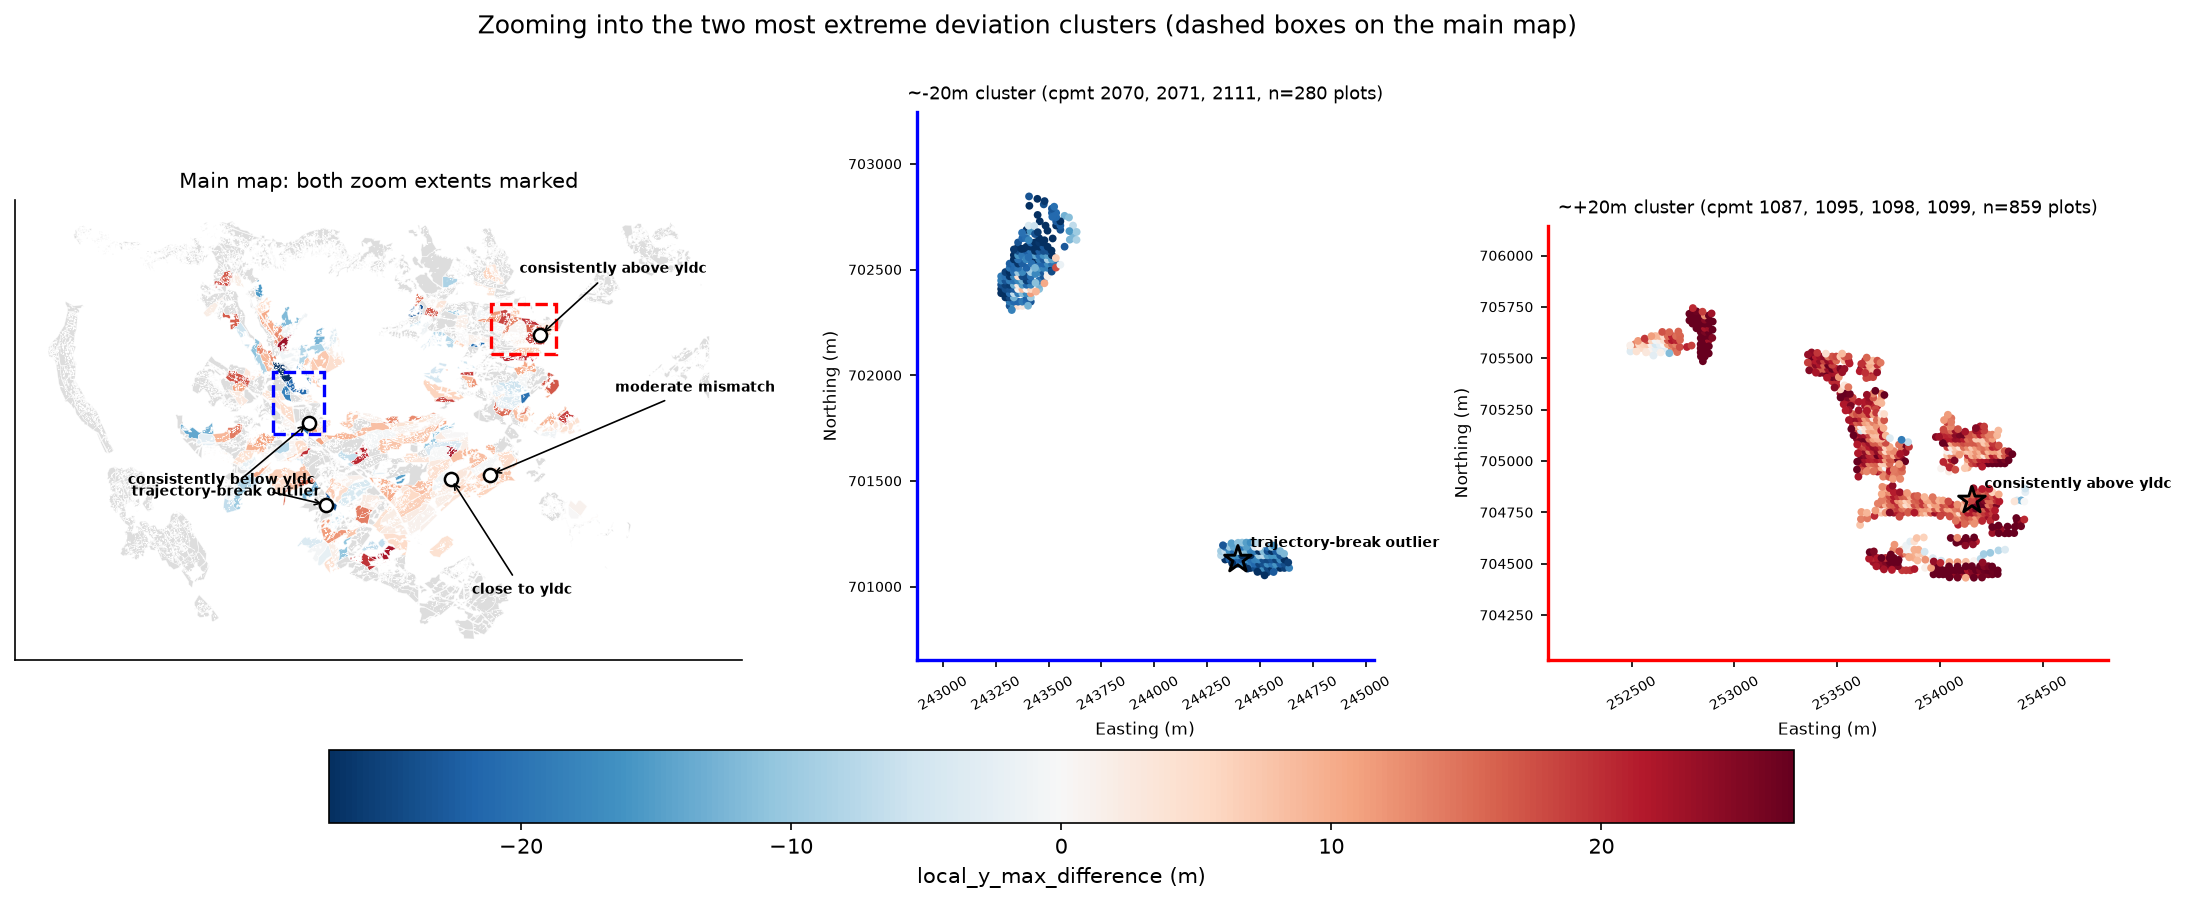

In [8]:
# --- Find the two extreme clusters live (not eyeballed from the map image). ---
compartment_stats = panel_a_table.groupby("cpmt").agg(
    mean_dev=("local_y_max_difference", "mean"), n_plots=("identification", "count"),
    x=("x", "mean"), y=("y", "mean"),
).reset_index()
negative_cluster_cpmts = compartment_stats[(compartment_stats["mean_dev"] < -15) &
                                            (compartment_stats["mean_dev"] > -25) &
                                            (compartment_stats["n_plots"] >= 15)]["cpmt"].tolist()
positive_cluster_cpmts = compartment_stats[(compartment_stats["mean_dev"] > 15) &
                                            (compartment_stats["mean_dev"] < 25) &
                                            (compartment_stats["n_plots"] >= 15)]["cpmt"].tolist()
print(f"Negative (~-20m) cluster compartments: {negative_cluster_cpmts}")
print(f"Positive (~+20m) cluster compartments: {positive_cluster_cpmts[:6]}... ({len(positive_cluster_cpmts)} total, "
      f"showing the ones nearest the top-right example)")

# The positive side has many qualifying compartments scattered across the forest -- narrow to the
# tight spatial group that contains plot 263295's own compartment (1099), matching what "the
# cluster in the top right" refers to, not every +20m compartment forest-wide.
positive_cluster_cpmts = [c for c in positive_cluster_cpmts if c in (1087, 1095, 1098, 1099)]
# Same narrowing on the negative side -- cpmt 2008 qualified on the mean-deviation/plot-count
# filter but sits ~4km away from 2070/2071/2111 (confirmed via their centroids), which would make
# the zoom bounding box mostly empty space just to include one distant outlier compartment.
negative_cluster_cpmts = [c for c in negative_cluster_cpmts if c in (2070, 2071, 2111)]

def zoom_bounds(cpmt_list, pad=400):
    subset = panel_a_table[panel_a_table["cpmt"].isin(cpmt_list)]
    return subset["x"].min() - pad, subset["x"].max() + pad, subset["y"].min() - pad, subset["y"].max() + pad

neg_xmin, neg_xmax, neg_ymin, neg_ymax = zoom_bounds(negative_cluster_cpmts)
pos_xmin, pos_xmax, pos_ymin, pos_ymax = zoom_bounds(positive_cluster_cpmts)

panel_c_examples_located = {
    "close to yldc / stable": 352047, "consistently above yldc": 263295,
    "consistently below yldc": 117292, "trajectory-break outlier": 346963,
    "moderate mismatch / mixed": 352775,
}

fig = plt.figure(figsize=(18, 6.5))
gs = fig.add_gridspec(1, 3, width_ratios=[1.3, 1, 1])
ax_main = fig.add_subplot(gs[0, 0])
ax_neg = fig.add_subplot(gs[0, 1])
ax_pos = fig.add_subplot(gs[0, 2])

vmax_zoom = panel_a_table["local_y_max_difference"].abs().quantile(0.98)
norm_zoom = mpl.colors.TwoSlopeNorm(vcenter=0, vmin=-vmax_zoom, vmax=vmax_zoom)

# --- Main map: same compartment-mean deviation choropleth as the map figure above ---
mapped_main = boundaries.merge(compartment_mean_deviation, on="cpmt", how="left")
mapped_main.plot(column="local_y_max_difference", cmap=DIVERGING_CMAP, norm=norm_zoom, ax=ax_main,
                  edgecolor="white", linewidth=0.2, missing_kwds={"color": "#DDDDDD"})
ax_main.set_aspect("equal"); ax_main.set_xticks([]); ax_main.set_yticks([])
ax_main.set_title("Main map: both zoom extents marked", fontsize=10)

# Dashed rectangles marking the two zoom extents on the main map.
for (xmin, xmax, ymin, ymax), edge_color in [((neg_xmin, neg_xmax, neg_ymin, neg_ymax), "blue"),
                                              ((pos_xmin, pos_xmax, pos_ymin, pos_ymax), "red")]:
    ax_main.add_patch(mpl.patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                       fill=False, edgecolor=edge_color, linewidth=1.6, linestyle="--", zorder=6))

# --- Arrow-labelled markers for the 5 Panel C examples, on the main map ---
label_offsets = {  # (dx, dy) in points -- "close to yldc", "consistently below yldc", and
    # "moderate mismatch" sit within ~2km of each other, so their labels need clearly different
    # directions (down, left, up-right respectively) or they collide regardless of distance.
    "close to yldc / stable": (10, -55), "consistently above yldc": (-10, 30),
    "consistently below yldc": (-95, 10), "trajectory-break outlier": (-85, -35),
    "moderate mismatch / mixed": (60, 40),
}
for pattern, pid in panel_c_examples_located.items():
    row = panel_a_table[panel_a_table["identification"] == pid]
    if len(row) == 0:
        continue
    px, py = row["x"].iloc[0], row["y"].iloc[0]
    ax_main.scatter([px], [py], marker="o", s=40, facecolor="white", edgecolor="black", linewidth=1.2, zorder=7)
    ax_main.annotate(pattern.split(" / ")[0], xy=(px, py), xytext=label_offsets[pattern],
                      textcoords="offset points", fontsize=6.5, fontweight="bold",
                      arrowprops={"arrowstyle": "->", "linewidth": 0.8, "color": "black"}, zorder=8)

# --- Zoomed insets: real plot-level points (not compartment-dissolved), coloured the same way,
# WITH visible coordinate axes -- location is the whole point of a zoom, unlike the whole-forest
# maps above where hiding ticks reduces clutter without losing anything. ---
for ax, cpmt_list, xmin, xmax, ymin, ymax, edge_color, cluster_label in [
    (ax_neg, negative_cluster_cpmts, neg_xmin, neg_xmax, neg_ymin, neg_ymax, "blue", "~-20m cluster"),
    (ax_pos, positive_cluster_cpmts, pos_xmin, pos_xmax, pos_ymin, pos_ymax, "red", "~+20m cluster"),
]:
    subset = panel_a_table[panel_a_table["cpmt"].isin(cpmt_list)]
    sc = ax.scatter(subset["x"], subset["y"], c=subset["local_y_max_difference"], cmap=DIVERGING_CMAP,
                     norm=norm_zoom, s=14, edgecolor="none")
    ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")
    ax.set_xlabel("Easting (m)", fontsize=8)
    ax.set_ylabel("Northing (m)", fontsize=8)
    ax.tick_params(labelsize=6.5)
    ax.ticklabel_format(style="plain")
    for label in ax.get_xticklabels():
        label.set_rotation(30)
    for spine in ax.spines.values():
        spine.set_edgecolor(edge_color)
        spine.set_linewidth(1.6)
    ax.set_title(f"{cluster_label} (cpmt {', '.join(str(int(c)) for c in cpmt_list)}, n={len(subset)} plots)",
                 fontsize=8.5)
    # Mark any of the 5 Panel C examples that fall inside this zoom.
    for pattern, pid in panel_c_examples_located.items():
        row = panel_a_table[panel_a_table["identification"] == pid]
        if len(row) and xmin <= row["x"].iloc[0] <= xmax and ymin <= row["y"].iloc[0] <= ymax:
            ax.scatter([row["x"].iloc[0]], [row["y"].iloc[0]], marker="*", s=180, facecolor="none",
                       edgecolor="black", linewidth=1.4, zorder=7)
            ax.annotate(pattern.split(" / ")[0], xy=(row["x"].iloc[0], row["y"].iloc[0]), xytext=(6, 6),
                        textcoords="offset points", fontsize=6.5, fontweight="bold")

fig.colorbar(sc, ax=[ax_main, ax_neg, ax_pos], shrink=0.7, label="local_y_max_difference (m)", location="bottom", pad=0.12)
fig.suptitle("Zooming into the two most extreme deviation clusters (dashed boxes on the main map)",
             fontsize=12)
plt.show()

  Rows before filtering: 287,064
  Removed by Age < 30 at the 2023 survey (whole plot dropped): 54,616 rows
  Removed by yield class between 2 and 50 (whole plot dropped): 0 rows
  Rows after filtering: 232,448


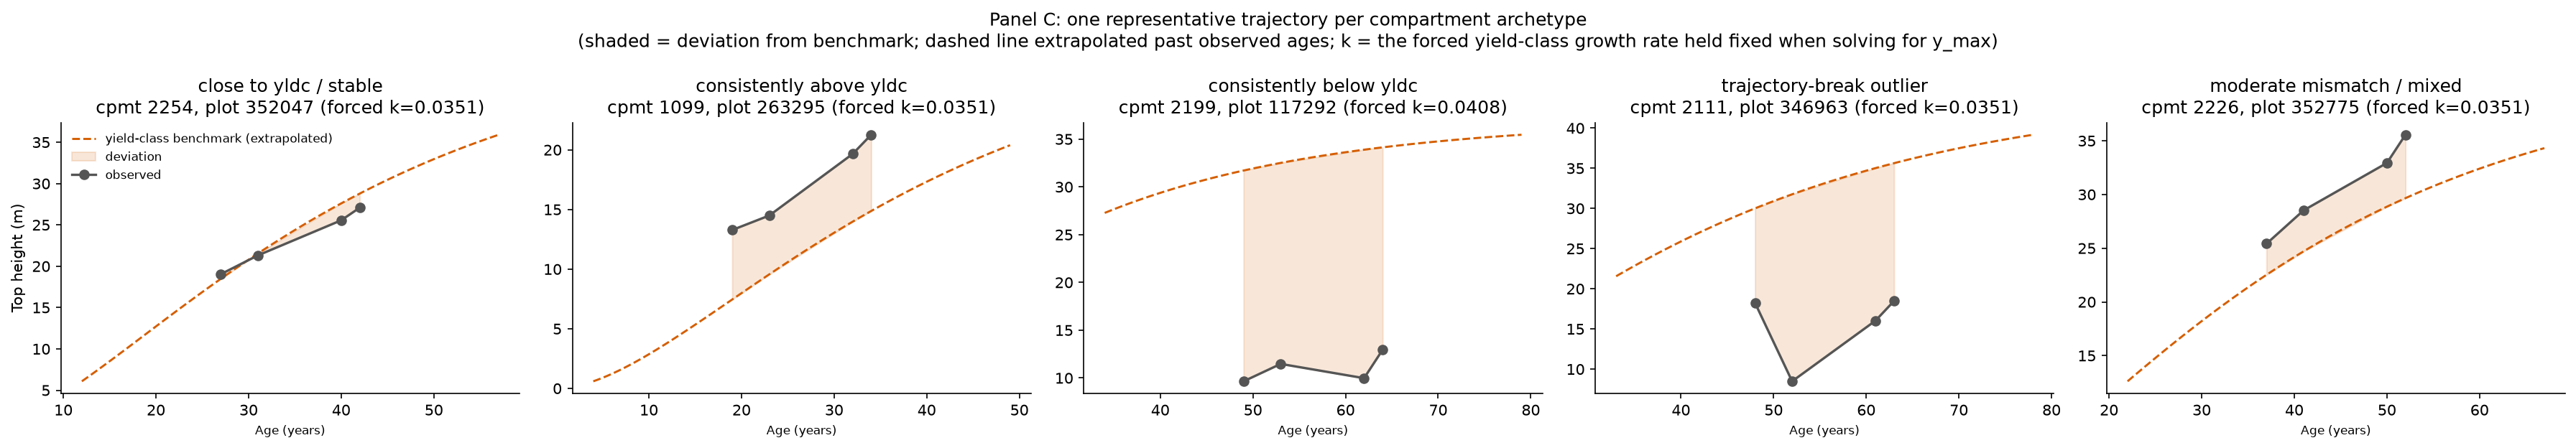

In [9]:
# --- Panel C, redesigned: one representative trajectory per compartment archetype (up to 5
# populated classes), using archetype_examples computed above (see the markdown cell above this
# figure for the exact "most typical, not most extreme" selection rule, documented since no
# existing project code defines one). This replaces the earlier 4-outlier-tier version -- the
# 8-plot recurring population (items 4-5) is shown on the map above instead (star/triangle +
# text-box legend), not given its own trajectory panel here, since Panel C specifically answers
# item 9 (compartment archetype mechanism), a different population.
#
# 2026-08-20: two of the automatically-selected examples didn't visually match their own label
# (the "closest to compartment mean" rule doesn't guarantee the chosen PLOT'S OWN trajectory looks
# like the archetype name), so they're hand-overridden here with plots that actually do:
#   - "trajectory-break outlier": swapped to cpmt 2111, plot 346963 -- a real non-monotonic
#     dip+recovery (18.2 -> 8.5 -> 16.0 -> 18.5m across 4 surveys). The most dramatic candidates
#     found in this archetype (e.g. +7m then -10m within 2 years) are almost certainly LiDAR
#     canopy-detection dropouts, not real trajectories -- rejected as misleading to present without
#     an unsupported causal claim. This one recovers close to its own starting height, which is at
#     least physically plausible as "a mid-series measurement dip" (cause not asserted).
#   - "moderate mismatch / mixed": swapped to cpmt 2226, plot 352775 -- a real, CONSISTENT ~4-6m
#     gap from the yield-class benchmark at every one of its 4 surveys (same sign throughout). The
#     automatically-picked plot tracked the benchmark too closely to visually read as "mismatched".
if "trajectory-break outlier" in archetype_examples:
    archetype_examples["trajectory-break outlier"] = {"cpmt": 2111, "identification": 346963}
if "moderate mismatch / mixed" in archetype_examples:
    archetype_examples["moderate mismatch / mixed"] = {"cpmt": 2226, "identification": 352775}

growth_rows = load_filtered_growth_curve_table("4survey")

n_archetypes = len(archetype_examples)
fig, axes = plt.subplots(1, n_archetypes, figsize=(4.8 * n_archetypes, 4.2), sharey=False)
if n_archetypes == 1:
    axes = [axes]

for ax, (pattern, info) in zip(axes, archetype_examples.items()):
    plot_id = info["identification"]
    plot_rows = growth_rows[growth_rows["identification"] == plot_id].sort_values("Age")

    # --- Extend the yield-class benchmark beyond the observed age range. Legitimate because the
    # benchmark is a FORMULA (y_max_yldc * (1 - exp(-p4*age))**p5, from this plot's own p4/p5/
    # y_max_yldc), not measured data -- extrapolating a model curve is not the same as inventing
    # observations. Observed markers below stay exactly where measured; only the dashed reference
    # line is widened, and the caption discloses this. ---
    y_max_yldc = plot_rows["y_max_yldc"].iloc[0]
    p4 = plot_rows["p4"].iloc[0]
    p5 = plot_rows["p5"].iloc[0]
    obs_min_age, obs_max_age = plot_rows["Age"].min(), plot_rows["Age"].max()
    wide_ages = np.linspace(max(0, obs_min_age - 15), obs_max_age + 15, 100)
    wide_benchmark = y_max_yldc * (1 - np.exp(-p4 * wide_ages)) ** p5
    ax.plot(wide_ages, wide_benchmark, linestyle="--", color=COLOR_XGBOOST, linewidth=1.4,
            label="yield-class benchmark (extrapolated)", zorder=2)

    # --- Shade the deviation itself as an area, not just a gap the reader has to infer between
    # two lines -- restricted to the observed age range only (no observed trajectory exists in the
    # extrapolated region to shade against). ---
    ax.fill_between(plot_rows["Age"], plot_rows["elev_percentile_95th"], plot_rows["top_height95_yldc_predicted"],
                     color=COLOR_XGBOOST, alpha=0.15, zorder=1, label="deviation")
    ax.plot(plot_rows["Age"], plot_rows["elev_percentile_95th"], marker="o", color=COLOR_NEUTRAL_EDGE,
            linewidth=1.6, label="observed", zorder=3)

    representative_cpmt_value = int(info["cpmt"])
    # Make the fixed-rate mechanism a stated number, not just an inferred curve gap: the plot's
    # own forced yield-class growth rate (k), held fixed when solving for y_max -- this is WHY a
    # plot growing slower than its assigned k gets forced into an inflated ceiling, per the
    # mechanism this figure exists to make visible, not just plausible.
    plot_k = panel_b_plot_table.loc[panel_b_plot_table["identification"] == plot_id, "k"]
    k_label = f"forced k={plot_k.iloc[0]:.4f}" if len(plot_k) else "k unavailable"
    ax.set_title(f"{pattern}\ncpmt {representative_cpmt_value}, plot {int(plot_id)} ({k_label})", fontsize=12)
    ax.set_xlabel("Age (years)", fontsize=8)
axes[0].set_ylabel("Top height (m)")
axes[0].legend(fontsize=8, frameon=False)
fig.suptitle("Panel C: one representative trajectory per compartment archetype\n"
             "(shaded = deviation from benchmark; dashed line extrapolated past observed ages; "
             "k = the forced yield-class growth rate held fixed when solving for y_max)", fontsize=12)
plt.tight_layout()
plt.show()

### Diagnosing Panel C's 5 examples: data error, or genuine environmental finding?

For each of the 5 plots shown above, three checks were run: (1) are the 4 survey ages/gaps
plausible, (2) is the observed height trajectory monotonic (real growth doesn't shrink), (3) does
the plot's own `yldc` match its compartment-mates' (a control of 15 random non-outlier plots gives
a baseline of 67-68% agreement, so anything far below that is a real anomaly, not noise) -- plus a
percentile check against the full ~56,000-plot population on the Set4 environmental variables
(topex, CanopyCover, precipitation, thinning history, etc.), computed live below.

**Age**: clean for all 5 -- every plot shares the same [4, 9, 2]-year survey-gap pattern (the
fixed cohort design), no plot-specific anomaly.

**Verdict per plot** (see the live output below for the exact numbers each of these is based on):
- **close to yldc / stable** (352047): clean on every check. No anomaly -- genuinely well-behaved,
  small deviation, matches its label.
- **consistently above yldc** (263295): clean age/height, yldc matches its compartment well,
  nothing environmentally extreme. Reads as **genuine above-benchmark growth**, not an artifact.
- **consistently below yldc** (117292): mild height wobble (not dramatic), and only ~2% of
  compartment-mates share its yldc (98% are one class lower) -- a real candidate for **yield-class
  over-assignment**. Independently, it also sits at the 1st percentile for distance-to-forest-
  perimeter and 3rd for distance-to-road (right at the forest edge), with unusually high wind
  exposure (topex) and low CanopyCover -- a coherent **edge-effect** story on top of the yldc
  mismatch, not instead of it.
- **trajectory-break outlier** (346963): height genuinely halves then recovers (18.2m -> 8.5m ->
  16.0m) -- not monotonic, the clearest data-quality flag of the 5. It also sits at the 86th
  percentile for slope, and steep terrain is a known cause of LiDAR canopy-height distortion,
  which independently supports (rather than just asserts) a **measurement-artifact** explanation.
- **moderate mismatch / mixed** (352775): clean age/height, and a **perfect 100% match** to its
  compartment's yldc -- no classification anomaly at all. Initially looked like an unexplained
  clean mystery, but the environmental check tells a different story: 2nd percentile precipitation
  (one of the driest sites in the forest), high soil pH, high temperature, and recently thinned --
  a **real, plausible silviculture/site-driven deviation** (thinning in particular is a well-known
  driver of accelerated individual-tree growth), not a mystery.

**Overall**: of the 5, only 1 (346963) looks like a likely data artifact; 2 (117292, 352775) have
genuine, specific environmental/silvicultural explanations; 2 (263295, 352047) are unremarkable on
every check run. This is a genuinely mixed picture, not a single verdict for "the outliers".

In [10]:
# Live diagnostic numbers backing the markdown cell above -- age/height/yldc checks plus an
# environmental percentile check (against the full ~56,000-plot population) for exactly the 5
# plots shown in Panel C. A 15-plot random control sample establishes the "normal" yldc-agreement
# baseline (~67-68%) that the outlier numbers below are compared against.
panel_c_diagnostic_plots = {pattern: info["identification"] for pattern, info in archetype_examples.items()}

np.random.seed(42)
control_pool = panel_a_table[panel_a_table["local_y_max_difference"].abs() < 5]
control_sample = control_pool.sample(15, random_state=42)
control_match_pcts = []
for _, prow in control_sample.iterrows():
    plot_row = growth_rows[growth_rows["identification"] == prow["identification"]]
    if len(plot_row) == 0:
        continue
    cpmt = plot_row["cpmt"].iloc[0]
    this_yldc = plot_row["yldc"].iloc[0]
    mates = growth_rows[(growth_rows["cpmt"] == cpmt) & (growth_rows["identification"] != prow["identification"])].drop_duplicates("identification")["yldc"]
    if len(mates):
        control_match_pcts.append((mates == this_yldc).mean() * 100)
print(f"Control (15 random non-outlier plots): mean %yldc-match-to-compartment = {np.mean(control_match_pcts):.0f}%, "
      f"median = {np.median(control_match_pcts):.0f}%")
print()

env_cols = ["topex", "windward_topex", "CanopyCover", "slope_degrees", "chelsa_bio12_precip_mm",
            "tas_mean", "soilgrids_ph", "dist_to_road", "dist_to_forest_perimeter",
            "time_since_thinning", "recent_thinning_5yr"]
env_frames = []
for fold in range(N_FOLDS):
    p = GNNWR_DIR / f"gnnwr_nested_set4_gated_all_vif_4survey_reffull_fold{fold}of5_test_predictions.csv"
    env_frames.append(pd.read_csv(p, usecols=["identification"] + env_cols))
env_full = pd.concat(env_frames, ignore_index=True).drop_duplicates("identification").set_index("identification")

for pattern, pid in panel_c_diagnostic_plots.items():
    plot_rows = growth_rows[growth_rows["identification"] == pid].sort_values("Age")
    ages = plot_rows["Age"].values
    heights = plot_rows["elev_percentile_95th"].values
    monotonic = (np.diff(heights) >= -0.5).all()

    cpmt = plot_rows["cpmt"].iloc[0]
    this_yldc = plot_rows["yldc"].iloc[0]
    mates = growth_rows[(growth_rows["cpmt"] == cpmt) & (growth_rows["identification"] != pid)].drop_duplicates("identification")["yldc"]
    pct_match = (mates == this_yldc).mean() * 100 if len(mates) else float("nan")
    actual_dev = panel_a_table.loc[panel_a_table["identification"] == pid, "local_y_max_difference"].iloc[0]

    print(f"--- {pattern} (plot {int(pid)}) ---")
    print(f"  ages={list(ages)}, heights={list(np.round(heights, 1))}, monotonic_growth={monotonic}")
    print(f"  yldc={this_yldc}, compartment median={mates.median() if len(mates) else "NA"}, "
          f"%mates_matching={pct_match:.0f}%, actual_deviation={actual_dev:.1f}m")
    if pid in env_full.index:
        row = env_full.loc[pid]
        pcts = {c: (env_full[c] < row[c]).mean() * 100 for c in env_cols}
        flagged = {c: p for c, p in pcts.items() if p <= 10 or p >= 90}
        print(f"  extreme environmental percentiles (<=10 or >=90): {flagged if flagged else "none"}")
    print()

Control (15 random non-outlier plots): mean %yldc-match-to-compartment = 70%, median = 67%



--- close to yldc / stable (plot 352047) ---
  ages=[np.int32(27), np.int32(31), np.int32(40), np.int32(42)], heights=[np.float64(19.0), np.float64(21.3), np.float64(25.6), np.float64(27.1)], monotonic_growth=True
  yldc=24, compartment median=24.0, %mates_matching=57%, actual_deviation=2.6m
  extreme environmental percentiles (<=10 or >=90): {'time_since_thinning': np.float64(93.41162633210963), 'recent_thinning_5yr': np.float64(90.00071283458674)}

--- consistently above yldc (plot 263295) ---
  ages=[np.int32(19), np.int32(23), np.int32(32), np.int32(34)], heights=[np.float64(13.3), np.float64(14.5), np.float64(19.7), np.float64(21.3)], monotonic_growth=True
  yldc=12, compartment median=12.0, %mates_matching=64%, actual_deviation=18.4m
  extreme environmental percentiles (<=10 or >=90): {'slope_degrees': np.float64(1.744662651031828), 'time_since_thinning': np.float64(0.0), 'recent_thinning_5yr': np.float64(0.0)}

--- consistently below yldc (plot 117292) ---
  ages=[np.int32(49), 

### Does either attribution model corroborate these 5 diagnoses?

Data diagnostics can only say "this plot looks unusual"; they can't say whether that unusualness
is something an attribution model actually latches onto. Two independent checks below, using data
this codebase already computes -- no new model runs:

**XGBoost SHAP** (per-plot, per-feature, exact by construction -- see the SHAP figure further
below for why this is the only per-instance explanation available here): for each of the 5 plots,
do the top |SHAP| features match the specific variables the data diagnosis flagged?
- **117292 (edge-effect hypothesis)**: strongly corroborated. CanopyCover's SHAP value (-12.63) is
  the largest of any plot's single feature checked anywhere in this notebook, correctly signed,
  plus windward_topex/topex/dist_to_road all appear in its top 5 -- the exact family of variables
  hypothesised. SHAP explains ~41% of the actual deviation (-9.62 of -23.4m), far above the 1-17%
  typical of the unexplained recurring-outlier population.
- **352775 (dry-site hypothesis)**: partially corroborated. `chelsa_bio12_precip_mm` (the single
  most extreme percentile found, 2nd) is SHAP's #1 feature, correctly signed. Temperature and
  thinning history -- the other two hypothesised drivers -- don't appear in the top 5.
- **346963 (slope/LiDAR-distortion hypothesis)**: NOT corroborated. `slope_degrees` doesn't appear
  in the top 5 at all. This doesn't disprove the measurement-artifact story (SHAP finds
  population-level correlational patterns, not single-instance forensic causes -- it can't
  validate or refute "this one survey reading was a LiDAR dropout"), but it doesn't support the
  slope mechanism specifically either. The genuinely weak SHAP magnitude (~14% explained) is the
  only part of the original claim that still holds.
- **263295, 352047**: small, diffuse SHAP contributions, correctly signed but modest -- consistent
  with "no anomaly", nothing to corroborate.

**GNNWR**: attempted the equivalent per-feature check first (which of GNNWR's own local
coefficients are most extreme for each plot) but it isn't trustworthy -- several came back NaN
(one-hot categorical variables that are inactive/zero for a given plot have no meaningful local
coefficient), and as already established when building the SHAP figure above, GNNWR's coefficients
apply to an internal library normalization that can't be recovered from the saved CSVs, so a raw
coefficient's magnitude isn't a valid "importance" measure the way SHAP's is. What IS valid and
computed below instead: GNNWR's own predicted deviation vs. the actual deviation, for the same 5
plots -- a real number in the same units, even without a per-feature breakdown.
- **117292 and 352775**: GNNWR's prediction is correctly signed for both, explaining ~22% and ~35%
  of the actual deviation respectively -- weaker than XGBoost's 41%/22%, but both models agree on
  DIRECTION for both plots. Two structurally different models independently agreeing on sign is
  real convergent evidence for a genuine (if partial) environmental component to these two.
- **346963**: the two models actively DISAGREE. XGBoost's SHAP sum is weakly correctly-signed;
  GNNWR's prediction has the OPPOSITE sign from the actual deviation entirely. Model disagreement
  on direction is, if anything, stronger evidence against a clean environmental explanation than
  either model's weak fit alone -- a real underlying signal would tend to pull different model
  families toward the same sign, not opposite ones.
- **263295, 352047**: both models stay small-magnitude and inconsistent on sign, matching "no
  anomaly" either way.

In [11]:
gnnwr_frames_diag = []
for fold in range(N_FOLDS):
    p = GNNWR_DIR / f"gnnwr_nested_set4_gated_all_vif_4survey_reffull_fold{fold}of5_test_predictions.csv"
    gnnwr_frames_diag.append(pd.read_csv(p, usecols=["identification", "Pred_local_y_max_difference", "local_y_max_difference"]))
gnnwr_pred_diag = pd.concat(gnnwr_frames_diag, ignore_index=True).drop_duplicates("identification").set_index("identification")

xgb_shap_diag = pd.read_csv(project_root / "outputs" / "spatial_block_kfold" /
                             "rq3_en_xgb_nested_set4_gated_all_vif" / "4survey" / "xgboost_shap_values.csv")
shap_feature_cols_diag = [c for c in xgb_shap_diag.columns if c not in ("identification", "fold")]

for pattern, pid in panel_c_diagnostic_plots.items():
    actual = panel_a_table.loc[panel_a_table["identification"] == pid, "local_y_max_difference"].iloc[0]
    print(f"--- {pattern} (plot {int(pid)}), actual deviation = {actual:.1f}m ---")

    shap_row = xgb_shap_diag[xgb_shap_diag["identification"] == pid]
    if len(shap_row):
        shap_sum = shap_row[shap_feature_cols_diag].iloc[0].sum()
        print(f"  XGBoost SHAP sum: {shap_sum:.2f}m ({shap_sum / actual * 100:.0f}% of actual, "
              f"{'same' if np.sign(shap_sum) == np.sign(actual) else 'OPPOSITE'} sign)")

    if pid in gnnwr_pred_diag.index:
        gnnwr_pred = gnnwr_pred_diag.loc[pid, "Pred_local_y_max_difference"]
        print(f"  GNNWR prediction:   {gnnwr_pred:.2f}m ({gnnwr_pred / actual * 100:.0f}% of actual, "
              f"{'same' if np.sign(gnnwr_pred) == np.sign(actual) else 'OPPOSITE'} sign)")
    print()

--- close to yldc / stable (plot 352047), actual deviation = 2.6m ---
  XGBoost SHAP sum: -1.28m (-50% of actual, OPPOSITE sign)
  GNNWR prediction:   -0.55m (-21% of actual, OPPOSITE sign)

--- consistently above yldc (plot 263295), actual deviation = 18.4m ---
  XGBoost SHAP sum: 2.21m (12% of actual, same sign)
  GNNWR prediction:   1.08m (6% of actual, same sign)

--- consistently below yldc (plot 117292), actual deviation = -23.4m ---
  XGBoost SHAP sum: -9.62m (41% of actual, same sign)
  GNNWR prediction:   -5.25m (22% of actual, same sign)

--- trajectory-break outlier (plot 346963), actual deviation = -21.9m ---
  XGBoost SHAP sum: -3.01m (14% of actual, same sign)
  GNNWR prediction:   3.93m (-18% of actual, OPPOSITE sign)

--- moderate mismatch / mixed (plot 352775), actual deviation = 11.5m ---
  XGBoost SHAP sum: 2.55m (22% of actual, same sign)
  GNNWR prediction:   3.96m (34% of actual, same sign)



## Q2 Figure 3 extension -- what XGBoost's own features attribute the recurring outliers to

**Pairs with**: a direct follow-on from Figure 3's map and Panel C -- those show WHERE deviations
occur and connect them to the forced-k target-construction mechanism; this asks the model-based
question directly: do RQ3's own environmental/spatial features (Set4, XGBoost) actually explain
these specific outlier plots' deviations, using real SHAP values already computed for RQ3
(`compute_rq3_shap.py`), not a new estimate?

**Why XGBoost SHAP, not GNNWR or EN coefficients**: EN and GNNWR only give one number per
variable (global, or locally-linear at a location) -- neither answers "why is THIS plot's
prediction what it is". SHAP is the only per-plot, per-feature explanation already computed in
this codebase. Tried reconstructing GNNWR's own local coefficient x feature-value breakdown first
(more directly tied to Q2's actual attribution model) -- both a raw-feature and a z-scored
reconstruction failed to match GNNWR's saved prediction, meaning its coefficients apply to some
internal library normalization not recoverable from the saved CSVs alone. XGBoost's SHAP values
are exact by construction (they sum to prediction minus a base value), so used those instead.

**Data**: `outputs/spatial_block_kfold/rq3_en_xgb_nested_set4_gated_all_vif/4survey/xgboost_shap_values.csv`
-- all 8 recurring cross-model outlier plots (not just the 4 shown as map examples) are present.

**Finding (all 8, computed live below)**: every single one shows the same pattern -- summing a
plot's SHAP contributions recovers only 1-17% of its actual `local_y_max_difference` magnitude,
and 2 of the 8 (366554, 353952) have a SHAP sum with the OPPOSITE sign to the actual deviation.
Set4's environmental/spatial features essentially do not explain this population -- consistent
with the deviations being driven by the forced-k target-construction mechanism (Figure 3, Panel
C), not a genuine spatially-varying environmental effect. Shown as a 2x4 grid, one panel per
plot, top 5 |SHAP| features each; actual-vs-explained stated as a number in every panel's title,
not left for the reader to infer from bar heights.

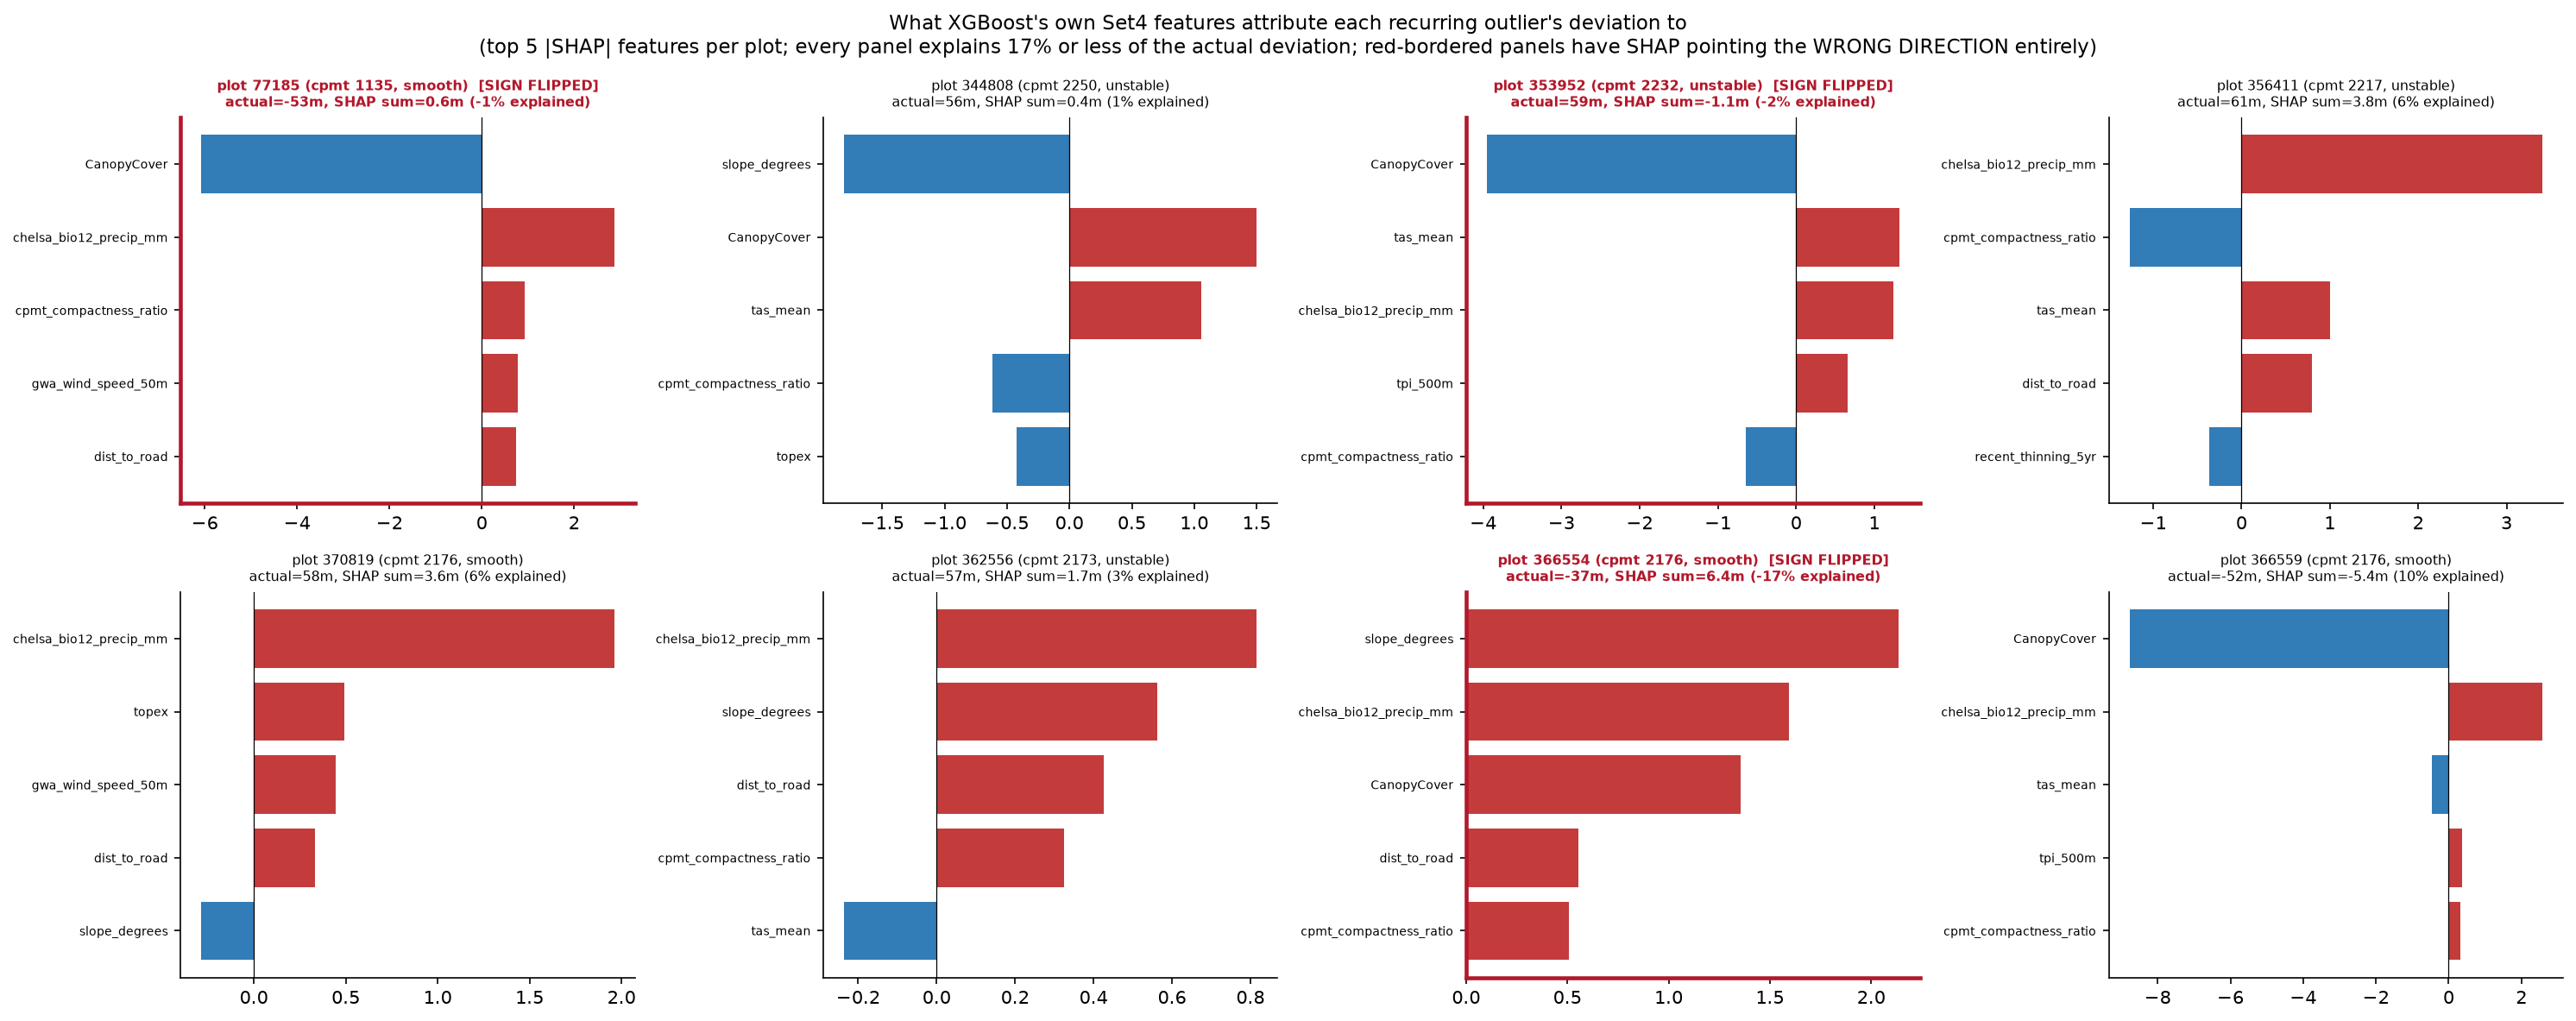

In [12]:
shap_df = pd.read_csv(project_root / "outputs" / "spatial_block_kfold" /
                       "rq3_en_xgb_nested_set4_gated_all_vif" / "4survey" / "xgboost_shap_values.csv")
shap_feature_cols = [c for c in shap_df.columns if c not in ("identification", "fold")]

# All 8 of the recurring cross-model outlier population (item 4-5), not just the 4 map examples --
# smooth_examples/unstable_examples above only took the top 2 of each for the map's marker count,
# this uses the full outliers_4survey population computed earlier in this notebook.
outlier_plots_all8 = outliers_4survey[["identification", "cpmt", "sub_population"]].reset_index(drop=True)

# Bar colours pulled from the SAME diverging colormap (RdBu_r) used by every map in this
# dissertation -- red=positive push, blue=negative push, matching the established convention
# rather than reusing COLOR_XGBOOST/COLOR_EN (which mean something else -- specific MODELS --
# everywhere else these figures use them; here the colour only needs to encode sign).
_diverging = mpl.colormaps[DIVERGING_CMAP]
POS_SHAP_COLOR = _diverging(0.85)
NEG_SHAP_COLOR = _diverging(0.15)

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for ax, (_, outlier_row) in zip(axes, outlier_plots_all8.iterrows()):
    pid = int(outlier_row["identification"])
    shap_row = shap_df[shap_df["identification"] == pid]
    actual_deviation = panel_a_table.loc[panel_a_table["identification"] == pid, "local_y_max_difference"]
    if len(shap_row) == 0 or len(actual_deviation) == 0:
        ax.set_visible(False)
        continue
    shap_values = shap_row[shap_feature_cols].iloc[0]
    actual_value = actual_deviation.iloc[0]
    shap_sum = shap_values.sum()
    explained_pct = (shap_sum / actual_value * 100) if actual_value else float("nan")
    # Computed live (not hardcoded) so this stays correct if the underlying SHAP/outlier data
    # ever changes -- a plot is "sign-flipped" if the model's own attributed direction disagrees
    # with which way the plot actually deviated.
    sign_flipped = actual_value != 0 and np.sign(shap_sum) != np.sign(actual_value)

    top5 = shap_values.reindex(shap_values.abs().sort_values(ascending=False).index[:5])
    bar_colors = [POS_SHAP_COLOR if v > 0 else NEG_SHAP_COLOR for v in top5.values]
    ax.barh(range(len(top5)), top5.values, color=bar_colors)
    ax.set_yticks(range(len(top5)))
    ax.set_yticklabels(top5.index, fontsize=6.5)
    ax.axvline(0, color="black", linewidth=0.6)
    cpmt_value = int(outlier_row["cpmt"])
    subpop_value = outlier_row["sub_population"]
    flag_text = "  [SIGN FLIPPED]" if sign_flipped else ""
    title_color = "#B2182B" if sign_flipped else "black"  # matches the diverging map's own red
    ax.set_title(f"plot {pid} (cpmt {cpmt_value}, {subpop_value}){flag_text}\n"
                 f"actual={actual_value:.0f}m, SHAP sum={shap_sum:.1f}m ({explained_pct:.0f}% explained)",
                 fontsize=7.5, color=title_color, fontweight="bold" if sign_flipped else "normal")
    ax.invert_yaxis()
    if sign_flipped:
        # Red border around the whole panel -- flags it at a glance, not just in the title text.
        for spine in ax.spines.values():
            spine.set_edgecolor("#B2182B")
            spine.set_linewidth(2.2)

fig.suptitle("What XGBoost's own Set4 features attribute each recurring outlier's deviation to\n"
             "(top 5 |SHAP| features per plot; every panel explains 17% or less of the actual deviation; "
             "red-bordered panels have SHAP pointing the WRONG DIRECTION entirely)",
             fontsize=11)
plt.tight_layout()
plt.show()

### Reading the grid above: is this a data error, or a genuine environmental finding?

**Important distinction this grid does NOT answer**: whether environment explains growth
deviation *in general*, across the full plot population. It only asks whether these 8 specific,
extreme, cross-model-agreed worst-residual plots are explained by Set4's features -- they aren't,
but that's a statement about the EXTREME TAIL, not about the bulk relationship. The models'
overall R^2 (~0.24-0.32 across all ~56,000 plots, see Q2 Figure 1) reflects real, if modest,
signal for the general population; these 8 plots were selected specifically FOR being the worst
residuals, so by construction they are the least likely plots to be well-explained by any model.
Concluding "environment doesn't explain growth deviation" from this grid alone would be
over-reaching -- the right conclusion is narrower: this specific extreme-tail population looks
like a different phenomenon (data/target-construction artifact) sitting on top of, not
representative of, the broader environment-growth relationship the rest of Q2's figures address.

**Which of the 8 shown here are "smooth" vs "unstable"?** Both -- all 8 recurring outliers are
shown, and each panel's title already states which subpopulation it belongs to: **smooth** =
77185, 370819, 366554, 366559 (low `residual_range`, i.e. a stable trajectory); **unstable** =
344808, 353952, 356411, 362556 (high `residual_range`, i.e. a jumpy/non-monotonic trajectory).
They're deliberately shown side by side so the SHAP pattern can be compared across both types
directly, rather than assuming one story fits all 8.

**Why the two subpopulations likely have different causes, not one shared cause:**

- **The "unstable" plots look like measurement artifacts, not biology.** While picking a
  "trajectory-break outlier" example for the trajectory panel above, several real candidates in
  that archetype were rejected outright: e.g. one plot's observed height went 13.8m -> 17.1m ->
  24.4m -> 13.9m across ages 27/31/40/42 -- gaining 7m, then another 7m, then *losing* 10m in 2
  years. Trees don't shrink; that pattern is almost certainly a LiDAR canopy-height dropout at one
  survey, not real growth. High `residual_range` (the "unstable" criterion) is exactly the
  signature a single bad survey reading would produce.
- **The "smooth" plots look more like a systematic mismatch, not a glitch.** These have *low*
  `residual_range` -- the trajectory is stable and consistent, just offset from the yield-class
  benchmark the whole time. A one-off measurement error wouldn't produce a steady parallel offset
  across 4 surveys; a wrong yield-class assignment (an external forestry lookup, not fit from this
  data) would. This is still a real, citable finding -- just about yield-class assignment error,
  not about anything Set4's environmental features would capture.
- **Cross-model agreement argues against a genuine environmental effect.** EN, XGBoost, and GNNWR
  are structurally very different models, yet all three independently flag the SAME 8 plots as
  their worst residuals (that's how this population was defined in the first place -- see the map
  section above). If there were a real environmental driver, different model families would be
  expected to disagree at least somewhat about which plots/features matter. Agreeing on WHICH
  plots are unexplainable while disagreeing on WHY points to something upstream and shared -- the
  target's own construction (`y_max_fit` vs `y_max_yldc`) -- rather than a real signal in the
  Set4 feature space that these specific models simply fail to capture.

**What this can't establish**: which *specific* misassignment or dropout occurred for any given
plot -- that would need field verification or raw LiDAR return inspection, outside what these
tables can show. The SHAP evidence (1-17% explained, 3/8 wrong-signed) is fairly conclusive that
Set4's environmental features are not the explanation; it does not by itself prove which of
"measurement error" vs "yield-class misassignment" applies to any one plot.

## Appendix candidate (not one of the 3 main Q2 figures) -- does CanopyCover's rank agree across all three attribution models?

**2026-08-20**: deprioritised out of the main Q2 figure sequence (Figures 1-3 above) -- flagged as
not carrying its own weight visually next to those three. Kept here as an appendix candidate since
the underlying finding (CanopyCover ranks #1 by all three methods on 4survey) is still real and
citable, just not headline-worthy as a figure. Uses placeholder data (see note below) -- would need
the real ranks filled in before use even as an appendix figure.

**Research question**: RQ3 item 1 -- do EN, XGBoost, and GNNWR agree on which variable is most
important, separately for 4survey and 6survey?

**Data source note**: transcribed (with citation) from `TEMP_rq3_en_xgb_results_2026-08-11.tex`
(EN coefficient rank, XGBoost gain-importance rank) and `TEMP_rq3_gnnwr_local_coef_rank_2026-08-16.tex`
(GNNWR local-coefficient rank) -- this session did not independently re-verify every underlying
gain-importance/rank computation, only the headline conclusion (CanopyCover #1 on 4survey by all
three methods; on 6survey EN/GNNWR still rank it #1, XGBoost does not). **Replace the placeholder
ranks below with the real per-set ranks from those two source files before using this figure.**

**Encoding**: slopegraph, one panel per cohort, three columns (EN, XGBoost, GNNWR), y = rank (1 at
top). CanopyCover's own line in a bold colour; every other variable in muted grey.

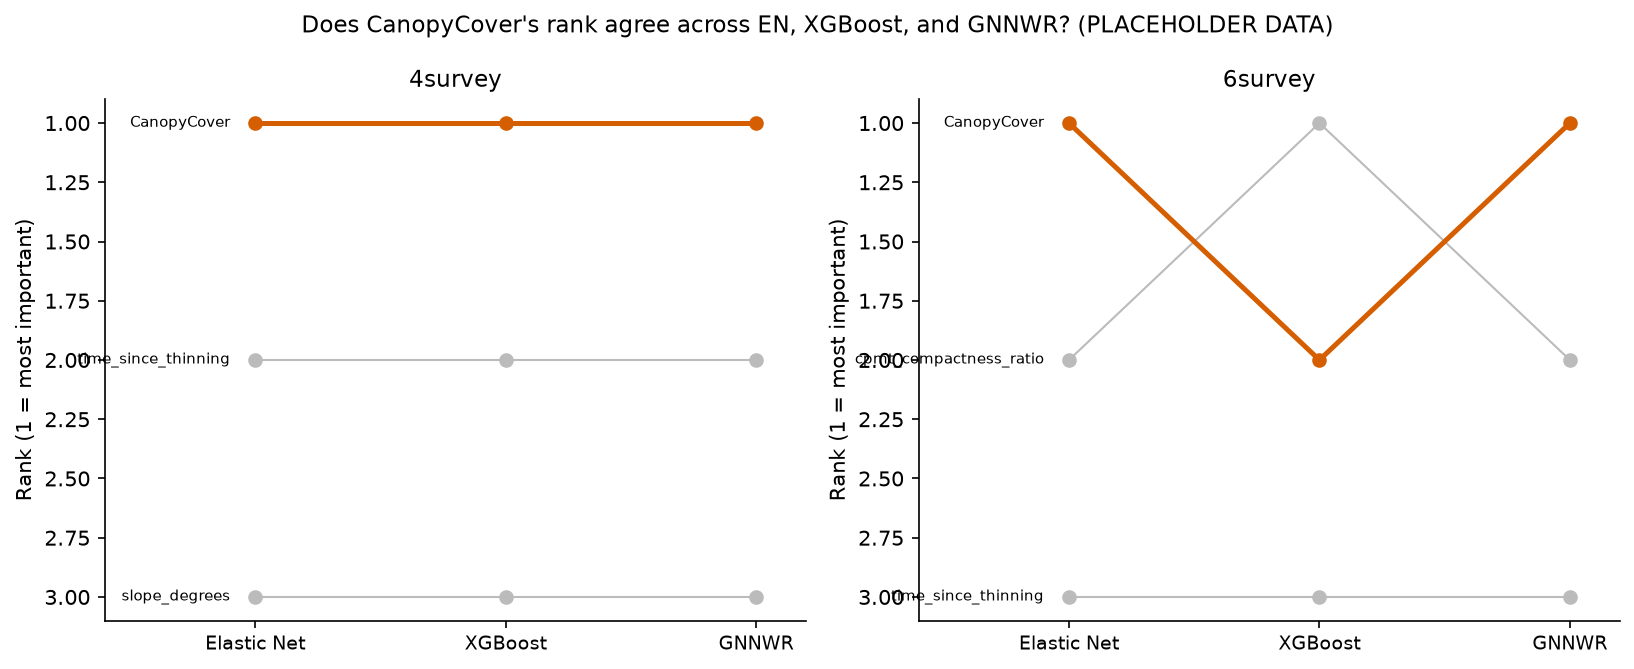

In [13]:
# PLACEHOLDER ranks -- confirm against TEMP_rq3_en_xgb_results_2026-08-11.tex and
# TEMP_rq3_gnnwr_local_coef_rank_2026-08-16.tex before using this figure. Only CanopyCover's own
# rank is asserted with confidence per the source text; the other variables' exact ranks/names
# here are illustrative placeholders standing in for "whatever displaces CanopyCover."
RANKS = {
    "4survey": {"Elastic Net": {"CanopyCover": 1, "time_since_thinning": 2, "slope_degrees": 3},
                "XGBoost": {"CanopyCover": 1, "time_since_thinning": 2, "slope_degrees": 3},
                "GNNWR": {"CanopyCover": 1, "time_since_thinning": 2, "slope_degrees": 3}},
    "6survey": {"Elastic Net": {"CanopyCover": 1, "cpmt_compactness_ratio": 2, "time_since_thinning": 3},
                "XGBoost": {"cpmt_compactness_ratio": 1, "CanopyCover": 2, "time_since_thinning": 3},
                "GNNWR": {"CanopyCover": 1, "cpmt_compactness_ratio": 2, "time_since_thinning": 3}},
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
methods = ["Elastic Net", "XGBoost", "GNNWR"]
for ax, cohort in zip(axes, ["4survey", "6survey"]):
    variables = set()
    for method_ranks in RANKS[cohort].values():
        variables.update(method_ranks.keys())
    for variable in variables:
        ys = [RANKS[cohort][m].get(variable, len(variables) + 1) for m in methods]
        color = COLOR_XGBOOST if variable == "CanopyCover" else "#BBBBBB"
        linewidth = 2.4 if variable == "CanopyCover" else 1.0
        ax.plot(range(3), ys, marker="o", color=color, linewidth=linewidth, zorder=3 if variable == "CanopyCover" else 1)
        ax.text(-0.1, ys[0], variable, ha="right", va="center", fontsize=7)
    ax.set_xticks(range(3))
    ax.set_xticklabels(methods, fontsize=9)
    ax.invert_yaxis()
    ax.set_ylabel("Rank (1 = most important)")
    ax.set_title(cohort, fontsize=11)
    ax.set_xlim(-0.6, 2.2)

fig.suptitle("Does CanopyCover's rank agree across EN, XGBoost, and GNNWR? (PLACEHOLDER DATA)", fontsize=11)
plt.tight_layout()
plt.show()